In [105]:
from pathlib import Path

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pandas import DataFrame

from caveat.evaluate.describe import transitions as describe_transitions
from caveat.evaluate.describe.frequency import frequency_plots
from caveat.evaluate.describe.times import (
    joint_time_distributions_plot,
    times_distributions_plot,
)
from caveat.evaluate.describe.transitions import sequence_prob_plot
from caveat.evaluate.features import participation, times, transitions

In [106]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}

batch_paths = {
    # "Disc RNN": Path("../logs/TRB/discrim"),
    "Conditional": Path("../logs/TRB/conditional"),
    "Generative": Path("../logs/TRB/vae"),
    # "JVAE": Path("../logs/TRB/jvae"),
    "CVAE": Path("../logs/TRB/cvae"),
}

# find data
target_schedules = pd.read_csv("../tmp/nts_schedules_2023.csv")
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv("../tmp/nts_attributes_2023.csv")


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "domain_distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "domain_distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))] for k, v in splits
    }


next(find_nth(Path("../logs/paper_d_rnn")))

('DiscLSTM5', PosixPath('../logs/paper_d_rnn/DiscLSTM5/version_1'))

In [107]:
schedules = {
    n: pd.read_csv(next(best_quality(p, 0))[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(next(best_quality(p, 0))[1], default=target_attributes)
    for n, p in batch_paths.items()
}

Loading synthetic attributes from ../logs/TRB/conditional/conditional_nrun0/version_4
Failed to find attributes at ../logs/TRB/vae/vae_nrun0/version_3
Loading synthetic attributes from ../logs/TRB/cvae/cvae_nrun0/version_5


In [108]:
target_attributes.head()

,pid,age,gender,ethnicity,education,license,car_access,work_status,mobility,wheelchair_user,...,income,hh_size,hh_composition,hh_children,hh_cars,hh_bikes,hh_motorcycles,blue_badge,num_license_holders,age_group
0,0,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
1,1,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
2,2,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
3,3,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+
4,4,80,M,white,Y,yes,yes,employed,none,unknown,...,2,2,2adults,0,2,0,0,no,2,70+


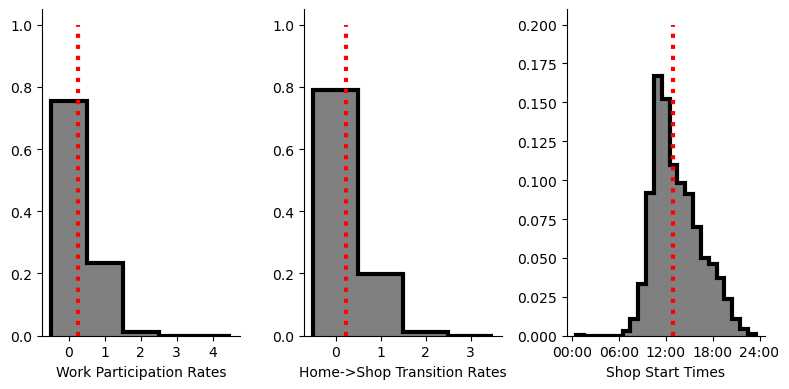

In [109]:
fs = 10
fig, ax = plt.subplots(1, 3, figsize=(8, 4), sharey=False)

act = "work"
bins, counts = participation.participation_rates_by_act(target_schedules)[act]
expected = np.average(bins, weights=counts) + 0.5
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[0].stairs(counts, bins, lw=3, ec="black", fc="grey", fill=True)
ax[0].vlines(expected, 0, 1, lw=3, ls=":", color="red")

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(ticks, bins)
ax[0].set_xlabel("Work Participation Rates", fontsize=fs)

# =============
bins, counts = transitions.transitions_by_act(target_schedules)["home>shop"]
expected = np.average(bins, weights=counts) + 0.5
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[1].stairs(counts, bins, lw=3, ec="black", fc="grey", fill=True)
ax[1].vlines(expected, 0, 1, lw=3, ls=":", color="red")
bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(ticks, bins)
ax[1].set_xlabel("Home->Shop Transition Rates", fontsize=fs)

# =============

step = 60
act = "shop"
bins, counts = times.start_times_by_act(
    target_schedules, bin_size=step, factor=1
)[act]
expected = np.average(bins, weights=counts) + 0.5
counts = counts / counts.sum()
lookup = dict(zip(bins, counts))

target_bins = pd.Series([i for i in range(0, 1440, step)])
target_bins += step / 2

values = [0] * len(target_bins)

for i, b in enumerate(target_bins):
    values[i] = lookup.get(b, 0)

ax[2].stairs(values[:-1], target_bins, lw=3, fill=True, ec="black", fc="grey")
ax[2].vlines(expected, 0, 0.2, lw=3, ls=":", color="red")
bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[2].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[2].set_xlabel("Shop Start Times", fontsize=fs)

# remove outlines
for i in range(3):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    # ax[i].spines["left"].set_visible(False)
    # ax[i].spines["bottom"].set_visible(False)

fig.tight_layout()

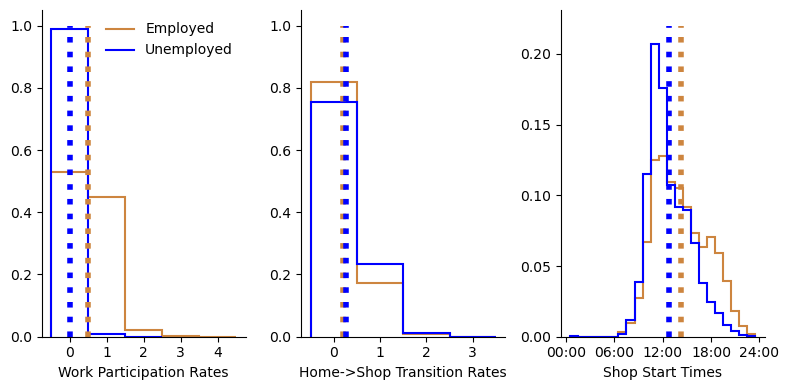

In [110]:
fs = 10
fig, ax = plt.subplots(1, 3, figsize=(8, 4), sharey=False)
split = split_on(target_schedules, target_attributes, by="work_status")
split = {
    # "Student": split["student"],
    "Employed": split["employed"],
    "Unemployed": split["unemployed"],
}
cmap2 = {"Employed": "peru", "Unemployed": "blue"}

act = "work"

for i, (k, v) in enumerate(split.items()):
    bins, counts = participation.participation_rates_by_act(v)[act]
    expected = np.average(bins, weights=counts) + 0.5
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()

    ax[0].stairs(counts, bins, lw=1.5, label=k, ls="-", color=cmap2[k])
    ax[0].vlines(expected, 0, 1, lw=4, ls=":", color=cmap2[k])

bins, counts = participation.participation_rates_by_act(target_schedules)[act]
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(ticks, bins)
ax[0].set_xlabel(f"{act.title()} Participation Rates", fontsize=fs)

# =============
transition = "home>shop"

for i, (k, v) in enumerate(split.items()):
    bins, counts = transitions.transitions_by_act(v)[transition]
    expected = np.average(bins, weights=counts) + 0.5
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()

    ax[1].stairs(counts, bins, lw=1.5, label=k, ls="-", color=cmap2[k])
    ax[1].vlines(expected, 0, 1, lw=4, ls=":", color=cmap2[k])


bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(ticks, bins)
ax[1].set_xlabel("Home->Shop Transition Rates", fontsize=fs)

# =============

step = 60
act = "shop"

for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    expected = np.average(bins, weights=counts) + step / 2
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for i, b in enumerate(target_bins):
        values[i] = lookup.get(b, 0)

    ax[2].stairs(
        values[:-1], target_bins, lw=1.5, ls="-", label=k, color=cmap2[k]
    )
    ax[2].vlines(expected, 0, 0.22, lw=4, ls=":", color=cmap2[k])

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[2].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[2].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

ax[0].legend(loc="upper right", frameon=False)

# remove outlines
for i in range(3):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.tight_layout()

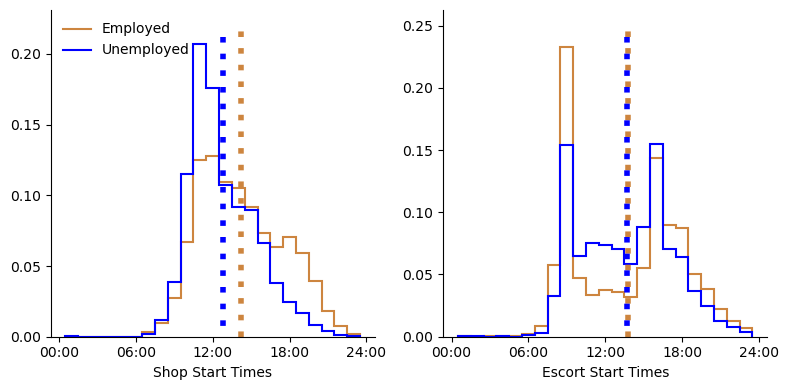

In [111]:
fs = 10
fig, ax = plt.subplots(1, 2, figsize=(8, 4), sharey=False)
split = split_on(target_schedules, target_attributes, by="work_status")
split = {
    # "Student": split["student"],
    "Employed": split["employed"],
    "Unemployed": split["unemployed"],
}
cmap2 = {"Employed": "peru", "Unemployed": "blue"}

step = 60
act = "shop"

for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    expected = np.average(bins, weights=counts) + step / 2
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for j, b in enumerate(target_bins):
        values[j] = lookup.get(b, 0)

    ax[0].stairs(
        values[:-1], target_bins, lw=1.5, ls="-", label=k, color=cmap2[k]
    )
    ax[0].vlines(expected, 0, 0.22, lw=4, ls=(i, (1, 2)), color=cmap2[k])

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[0].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

# =============
step = 60
act = "escort"

for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    expected = np.average(bins, weights=counts) + step / 2
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for j, b in enumerate(target_bins):
        values[j] = lookup.get(b, 0)

    ax[1].stairs(
        values[:-1], target_bins, lw=1.5, ls="-", label=k, color=cmap2[k]
    )
    ax[1].vlines(expected, 0, 0.25, lw=4, ls=(i, (1, 2)), color=cmap2[k])

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[1].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

ax[0].legend(loc="upper left", frameon=False)

# remove outlines
for i in range(2):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)

fig.tight_layout()

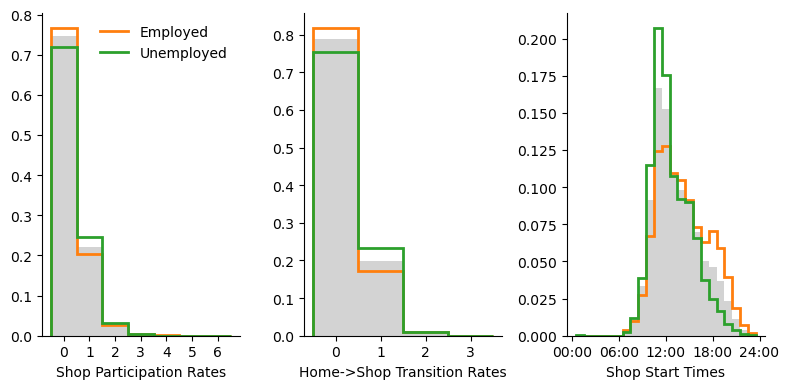

In [112]:
fs = 10
fig, ax = plt.subplots(1, 3, figsize=(8, 4), sharey=False)
split = split_on(target_schedules, target_attributes, by="work_status")
split = {
    # "Student": split["student"],
    "Employed": split["employed"],
    "Unemployed": split["unemployed"],
}


act = "shop"
bins, counts = participation.participation_rates_by_act(target_schedules)[act]
minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[0].stairs(counts, bins, fc="lightgrey", fill=True)

for i, (k, v) in enumerate(split.items()):
    bins, counts = participation.participation_rates_by_act(v)[act]
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()

    ax[0].stairs(counts, bins, lw=2, label=k)

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[0].set_xticks(ticks, bins)
ax[0].set_xlabel(f"{act.title()} Participation Rates", fontsize=fs)

# =============
transition = "home>shop"
bins, counts = transitions.transitions_by_act(target_schedules)[transition]

minimum = int(bins[0])
maximum = int(bins[-1])
bins = range(minimum, maximum + 2)
counts = counts / counts.sum()

ax[1].stairs(counts, bins, fc="lightgrey", fill=True)

for i, (k, v) in enumerate(split.items()):
    bins, counts = transitions.transitions_by_act(v)[transition]
    minimum = int(bins[0])
    maximum = int(bins[-1])
    bins = range(minimum, maximum + 2)
    counts = counts / counts.sum()
    ax[1].stairs(counts, bins, lw=2, label=k)


bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[1].set_xticks(ticks, bins)
ax[1].set_xlabel("Home->Shop Transition Rates", fontsize=fs)

# =============

step = 60
bins, counts = times.start_times_by_act(
    target_schedules, bin_size=step, factor=1
)[act]
counts = counts / counts.sum()
lookup = dict(zip(bins, counts))

target_bins = pd.Series([i for i in range(0, 1440, step)])
target_bins += step / 2

values = [0] * len(target_bins)

for i, b in enumerate(target_bins):
    values[i] = lookup.get(b, 0)

ax[2].stairs(values[:-1], target_bins, fill=True, fc="lightgrey")


for i, (k, v) in enumerate(split.items()):

    bins, counts = times.start_times_by_act(v, bin_size=step, factor=1).get(
        act, (pd.Series([0]), pd.Series([0]))
    )
    counts = counts / counts.sum()
    lookup = dict(zip(bins, counts))

    target_bins = pd.Series([i for i in range(0, 1440, step)])
    target_bins += step / 2

    values = [0] * len(target_bins)

    for i, b in enumerate(target_bins):
        values[i] = lookup.get(b, 0)

    ax[2].stairs(values[:-1], target_bins, lw=2, label=k)

bins = bins[:-1]
ticks = [i + 0.5 for i in bins]
ax[2].set_xticks(
    [0, 360, 720, 1080, 1440],
    labels=["00:00", "06:00", "12:00", "18:00", "24:00"],
    # rotation=90,
    fontsize=10,
)
ax[2].set_xlabel(f"{act.title()} Start Times", fontsize=fs)

ax[0].legend(loc="upper right", frameon=False)

# remove outlines
for i in range(3):
    ax[i].spines["top"].set_visible(False)
    ax[i].spines["right"].set_visible(False)
    # ax[i].spines["left"].set_visible(False)
    # ax[i].spines["bottom"].set_visible(False)

fig.tight_layout()

In [113]:
import ast


# losses
def iter_latest(path: Path):
    for dir in path.iterdir():
        if dir.is_dir():
            yield latest_run(dir)


def latest_run(path: Path):
    dirs = [
        p for p in path.iterdir() if p.is_dir() and p.name.startswith("version")
    ]
    return path.name, sorted(dirs)[-1]


def load_losses(path: Path):
    if not path.exists():
        return None
    with open(path) as f:
        lines = f.readlines()
    return lines


collected = pd.DataFrame()
for n, p in batch_paths.items():
    train_nll = []
    train_mse = []
    test_nll = []
    test_mse = []
    for name, m in iter_latest(p):
        loss_path = m / "best_loss.txt"
        losses = load_losses(loss_path)
        if losses is None:
            continue
        train_losses = ast.literal_eval(losses[0][7:])
        print(train_losses)
        train_nll.append(
            train_losses["test_act_recon"] / train_losses["test_act_weight"]
        )
        train_mse.append(
            train_losses["test_dur_recon"] / train_losses["test_dur_weight"]
        )

        test_losses = ast.literal_eval(losses[2][6:])
        test_nll.append(
            test_losses["test_act_recon"] / test_losses["test_act_weight"]
        )
        test_mse.append(
            test_losses["test_dur_recon"] / test_losses["test_dur_weight"]
        )

    train_nll = np.array(train_nll)
    train_mse = np.array(train_mse)
    test_nll = np.array(test_nll)
    test_mse = np.array(test_mse)

    collected[(n, "mean")] = pd.Series(
        {
            "train_nll": train_nll.mean(),
            "train_mse": train_mse.mean(),
            "test_nll": test_nll.mean(),
            "test_mse": test_mse.mean(),
        }
    )
    collected[(n, "var")] = pd.Series(
        {
            "train_nll": train_nll.var(),
            "train_mse": train_mse.var(),
            "test_nll": test_nll.var(),
            "test_mse": test_mse.var(),
        }
    )

collected[collected.isnull()] = 0
print(collected[::-1].to_latex(float_format="{:.5f}".format))

{'test_loss': 0.3035176694393158, 'test_recon_loss': 0.3035176694393158, 'test_act_recon': 0.04797862470149994, 'test_dur_recon': 0.25553908944129944, 'test_act_weight': 1.0, 'test_dur_weight': 200.0}
{'test_loss': 0.3029932677745819, 'test_recon_loss': 0.3029932677745819, 'test_act_recon': 0.04807090014219284, 'test_dur_recon': 0.25492238998413086, 'test_act_weight': 1.0, 'test_dur_weight': 200.0}
{'test_loss': 0.30523502826690674, 'test_recon_loss': 0.30523502826690674, 'test_act_recon': 0.04865177348256111, 'test_dur_recon': 0.25658324360847473, 'test_act_weight': 1.0, 'test_dur_weight': 200.0}
{'test_loss': 0.30308789014816284, 'test_recon_loss': 0.30308789014816284, 'test_act_recon': 0.0480661578476429, 'test_dur_recon': 0.25502172112464905, 'test_act_weight': 1.0, 'test_dur_weight': 200.0}
{'test_loss': 0.3031487762928009, 'test_recon_loss': 0.3031487762928009, 'test_act_recon': 0.04800449311733246, 'test_dur_recon': 0.25514423847198486, 'test_act_weight': 1.0, 'test_dur_weight':

In [ ]:
def build_distance_tables(batch_paths, suffix=""):
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / f"domain_distances{suffix}.csv"
        ).set_index("domain")

        columns = list(
            set(distances.columns) - set(["domain", "observed", "mean", "std"])
        )
        distances_combined[(name, "EMD")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    # distances_combined = distances_combined.set_index(
    #     pd.MultiIndex.from_tuples(distances_combined.index)
    # )

    return distances_combined


order = ["participations", "transitions", "timing", "feasibility", "creativity"]
df = build_distance_tables(batch_paths, suffix="")
print(df.loc[order].to_latex(float_format="{:.3f}".format))

# conditional
df = build_distance_tables(batch_paths, suffix="_subs")
print(df.loc[order].to_latex(float_format="{:.3f}".format))
df

\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{r}{Conditional} & \multicolumn{2}{r}{Generative} & \multicolumn{2}{r}{CVAE} \\
 & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  \\
\midrule
participations & 0.389 & 0.000 & 0.064 & 0.000 & 0.073 & 0.000 \\
transitions & 0.019 & 0.000 & 0.004 & 0.000 & 0.003 & 0.000 \\
timing & 0.172 & 0.000 & 0.024 & 0.000 & 0.029 & 0.000 \\
feasibility & 0.000 & 0.000 & 0.021 & 0.000 & 0.028 & 0.000 \\
creativity & 0.503 & 0.000 & 0.015 & 0.000 & 0.016 & 0.000 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{r}{Conditional} & \multicolumn{2}{r}{Generative} & \multicolumn{2}{r}{CVAE} \\
 & EMD & var & EMD & var & EMD & var \\
domain &  &  &  &  &  &  \\
\midrule
participations & 0.394 & 0.000 & 0.087 & 0.000 & 0.082 & 0.000 \\
transitions & 0.022 & 0.000 & 0.006 & 0.000 & 0.004 & 0.000 \\
timing & 0.180 & 0.000 & 0.032 & 0.000 & 0.031 & 0.000 \\
feasibility & 0.000 & 0.000 & 0.021 & 0.000 & 0.028 & 0.

Conditional           Generative                    CVAE  \
                       EMD       var        EMD           var       EMD   
domain                                                                    
creativity        0.500285  0.000005   0.008703  3.272084e-06  0.009841   
feasibility       0.000000  0.000000   0.021185  1.427918e-05  0.027858   
participations    0.393511  0.000003   0.086501  1.454595e-04  0.081639   
timing            0.180158  0.000025   0.032384  8.027378e-06  0.030964   
transitions       0.022465  0.000002   0.006459  1.982260e-07  0.004490   

                              
                         var  
domain                        
creativity      1.548578e-06  
feasibility     1.068569e-04  
participations  1.261090e-04  
timing          1.286095e-06  
transitions     5.275949e-07

In [115]:
def group_tables(batch_paths, suffix=""):
    distances_combined = pd.DataFrame()
    descriptions_combined = pd.DataFrame()
    variances_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        distances = pd.read_csv(
            path / f"group_distances{suffix}.csv"
        ).set_index(["domain", "feature"])
        descriptions = pd.read_csv(
            path / f"group_descriptions{suffix}.csv"
        ).set_index(["domain", "feature"])

        columns = set(distances.columns)
        columns = list(
            columns - set(["observed", "unit", "mean", "std", "sub_pop"])
        )

        print(name, columns)

        distances_combined[(name, "mean")] = distances[columns].mean(axis=1)
        distances_combined[(name, "var")] = distances[columns].var(axis=1)
        variances_combined[(name, "std")] = distances[columns].std(axis=1)
        descriptions_combined[(name, "mean")] = descriptions[columns].mean(
            axis=1
        )

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )
    variances_combined.columns = pd.MultiIndex.from_tuples(
        variances_combined.columns
    )
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return (
        distances_combined.loc[index],
        variances_combined,
        descriptions_combined.loc[index],
    )


dist_dist, dist_std, dist_desc = group_tables(batch_paths)
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))

# conditional
dist_dist, dist_std, dist_desc = group_tables(batch_paths, suffix="_subs")
print(dist_dist.droplevel(0, axis=0).to_latex(float_format="{:.3f}".format))

Conditional ['conditional_nrun1', 'conditional_nrun3', 'conditional_nrun0', 'conditional_nrun4', 'conditional_nrun2']
Generative ['vae_nrun4', 'vae_nrun0', 'vae_nrun2', 'vae_nrun1', 'vae_nrun3']
CVAE ['cvae_nrun1', 'cvae_nrun3', 'cvae_nrun4', 'cvae_nrun2', 'cvae_nrun0']
\begin{tabular}{lrrrrrr}
\toprule
 & \multicolumn{2}{r}{Conditional} & \multicolumn{2}{r}{Generative} & \multicolumn{2}{r}{CVAE} \\
 & mean & var & mean & var & mean & var \\
feature &  &  &  &  &  &  \\
\midrule
lengths & 0.955 & 0.000 & 0.160 & 0.002 & 0.185 & 0.001 \\
pair participation rate & 0.017 & 0.000 & 0.003 & 0.000 & 0.004 & 0.000 \\
participation rate & 0.195 & 0.000 & 0.029 & 0.000 & 0.031 & 0.000 \\
2-gram & 0.050 & 0.000 & 0.008 & 0.000 & 0.007 & 0.000 \\
3-gram & 0.006 & 0.000 & 0.002 & 0.000 & 0.002 & 0.000 \\
4-gram & 0.002 & 0.000 & 0.001 & 0.000 & 0.001 & 0.000 \\
durations & 0.100 & 0.000 & 0.015 & 0.000 & 0.019 & 0.000 \\
joint-durations & 0.245 & 0.000 & 0.038 & 0.000 & 0.044 & 0.000 \\
start time

In [130]:
def build_all_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions.csv").set_index(
            ["domain", "feature", "segment"]
        )
        distances = pd.read_csv(path / "distances.csv").set_index(
            ["domain", "feature", "segment"]
        )
        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(
                [
                    "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
            - weights
        )
        descriptions_combined[name, "mean"] = descriptions[columns].mean(axis=1)
        # descriptions_combined[name, "var"] = descriptions[columns].var(axis=1)
        descriptions_combined[name, "EMD"] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["unit"]
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )
    descriptions_combined = descriptions_combined.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(
        lambda x: x.sort_values([("Observed", "")], ascending=False).head(20)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return descriptions_combined.loc[index, order]


table = build_all_description_tables(batch_paths)

p = table.loc["participations"]
for name in ["lengths", "participation rate", "pair participation rate"]:
    print(name)
    print(p.loc[name].to_latex(float_format="{:.3f}".format))
    print()

table.loc["participations"]

lengths
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Conditional} & \multicolumn{2}{r}{Generative} & \multicolumn{2}{r}{CVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
sequence lengths & 3.894 & 3.001 & 0.955 & 3.843 & 0.160 & 3.782 & 0.185 & length. \\
\bottomrule
\end{tabular}


participation rate
\begin{tabular}{lrrrrrrrl}
\toprule
 & Observed & \multicolumn{2}{r}{Conditional} & \multicolumn{2}{r}{Generative} & \multicolumn{2}{r}{CVAE} & Description \\
 &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment &  &  &  &  &  &  &  &  \\
\midrule
home & 2.306 & 2.001 & 0.337 & 2.270 & 0.055 & 2.263 & 0.060 & av. rate \\
other & 0.524 & 0.363 & 0.161 & 0.502 & 0.032 & 0.540 & 0.034 & av. rate \\
shop & 0.291 & 0.025 & 0.266 & 0.283 & 0.021 & 0.268 & 0.036 & av. rate \\
work & 0.256 & 0.471 & 0.238 & 0.257 & 0.019 & 0.260 & 0.013 & av. rate \\
escort & 0.256 & 0.007 & 0.249 & 0.232 & 0.044 & 0.197

Observed Conditional            \
                                                             mean       EMD   
feature                 segment                                               
lengths                 sequence lengths     3.893647    3.001309  0.954702   
pair participation rate home+home            1.039079    1.000000  0.070261   
                        other+other          0.086476    0.000000  0.086476   
                        home+other           0.084029    0.000000  0.084029   
                        escort+escort        0.075458    0.000655  0.074803   
                        home+escort          0.072353    0.000655  0.071698   
                        shop+shop            0.033325    0.000000  0.033325   
                        home+shop            0.032701    0.000000  0.032701   
                        visit+visit          0.013397    0.000000  0.013397   
                        home+visit           0.013178    0.000000  0.013178   
                        work+work            0.011221    0.000000  0.011221   
                        home+work            0.011221    0.000000  0.011221   
                        other+escort         0.004775    0.000000  0.004775   
                        other+shop           0.002818    0.000000  0.002818   
                        escort+shop          0.002160    0.000000  0.002160   
                        other+visit          0.001873    0.000000  0.001873   
                        home+medical         0.001603    0.000000  0.001603   
                        medical+medical      0.001603    0.000000  0.001603   
                        education+education  0.001164    0.000000  0.001164   
                        home+education       0.001164    0.000000  0.001164   
                        visit+shop           0.000945    0.000000  0.000945   
participation rate      home                 2.306133    2.000655  0.336661   
                        other                0.523766    0.362625  0.161141   
                        shop                 0.291167    0.025384  0.265783   
                        work                 0.256425    0.471287  0.238249   
                        escort               0.256070    0.006854  0.249216   
                        visit                0.127647    0.000000  0.127647   
                        education            0.089581    0.134504  0.047286   
                        medical              0.042858    0.000000  0.042858   

                                            Generative                CVAE  \
                                                  mean       EMD      mean   
feature                 segment                                              
lengths                 sequence lengths      3.843381  0.160213  3.782293   
pair participation rate home+home             1.038114  0.020309  1.034722   
                        other+other           0.085092  0.005561  0.091059   
                        home+other            0.083449  0.004664  0.089706   
                        escort+escort         0.052841  0.022617  0.044110   
                        home+escort           0.050910  0.021443  0.042602   
                        shop+shop             0.035188  0.004725  0.036173   
                        home+shop             0.034452  0.004519  0.035275   
                        visit+visit           0.007411  0.007870  0.011379   
                        home+visit            0.007347  0.007708  0.011221   
                        work+work             0.014187  0.003682  0.013883   
                        home+work             0.014177  0.003692  0.013846   
                        other+escort          0.000256  0.004519  0.001573   
                        other+shop            0.000871  0.001947  0.000496   
                        escort+shop           0.000186  0.001974  0.000000   
                        other+visit           0.000152  0.001721  0.000310   
                        home+medic

In [ ]:
# t = table.loc["transitions"]
# for name in ["2-gram", "3-gram"]:
#     print(name)
#     print(t.loc[name].to_latex(float_format="{:.3f}".format))
#     print()

# table.loc["transitions"]

In [ ]:
# t = table.loc["timing"]
# for name in ["durations", "start times", "end times", "start-durations"]:
#     print(name)
#     print(t.loc[name].to_latex(float_format="{:.3f}".format))
#     print()

# table.loc["timing"]

In [219]:
def build_all_description_tables_subs(batch_paths, on="work_status"):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():
        label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
        label_distances = pd.read_csv(path / "label_distances_subs.csv")

        descriptions = pd.read_csv(path / "descriptions_subs.csv")
        distances = pd.read_csv(path / "distances_subs.csv")
        descriptions["label"] = on
        distances["label"] = on
        descriptions["cat"] = "combined"
        distances["cat"] = "combined"

        label_descriptions = pd.concat((label_descriptions, descriptions))
        label_distances = pd.concat((label_distances, distances))

        label_descriptions = (
            label_descriptions.loc[label_descriptions.label == on]
            .drop("label", axis=1)
            .set_index(["domain", "feature", "segment", "cat"])
        )
        label_distances = (
            label_distances.loc[label_distances.label == on]
            .drop("label", axis=1)
            .set_index(["domain", "feature", "segment", "cat"])
        )
        columns = set(label_descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(
                [
                    "observed",
                    "description",
                    "mean",
                    "std",
                    "feature count",
                    "unit",
                ]
            )
            - weights
        )
        descriptions_combined[name, "mean"] = label_descriptions[columns].mean(
            axis=1
        )
        descriptions_combined[name, "EMD"] = label_distances[columns].mean(
            axis=1
        )

    descriptions_combined["Observed", ""] = label_descriptions["observed"]
    descriptions_combined["Description", ""] = label_descriptions["unit"]
    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )
    descriptions_combined["maxi"] = descriptions_combined.Observed.groupby(
        ["domain", "feature", "segment"], group_keys=False
    ).transform("max")
    descriptions_combined = descriptions_combined.sort_values(
        ["maxi"], ascending=False
    ).drop(columns=["maxi"])

    descriptions_combined = descriptions_combined.groupby(
        ["domain", "feature"], group_keys=False
    ).apply(lambda x: x.head(1000))

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order = [("Observed", "")] + order

    index = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]

    return descriptions_combined.loc[index, order]


table = build_all_description_tables_subs(batch_paths)

p = table.loc["participations"]
for name in ["lengths", "participation rate"]:
    print(name)
    pp = p.loc[name]
    pp.loc[:, "Description"] = "rate"
    print(pp.to_latex(float_format="{:.3f}".format))
    print()

lengths
\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{Conditional} & \multicolumn{2}{r}{Generative} & \multicolumn{2}{r}{CVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment & cat &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{sequence lengths} & unemployed & 3.823 & 3.003 & 0.881 & 3.845 & 0.140 & 3.742 & 0.153 & rate \\
 & employed & 3.979 & 3.000 & 1.042 & 3.842 & 0.207 & 3.830 & 0.223 & rate \\
 & student & 3.475 & 3.000 & 0.555 & 3.845 & 0.383 & 3.562 & 0.182 & rate \\
 & combined & 3.894 & 3.001 & 0.955 & 3.843 & 0.198 & 3.782 & 0.202 & rate \\
\cline{1-10}
\bottomrule
\end{tabular}


participation rate
\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{Conditional} & \multicolumn{2}{r}{Generative} & \multicolumn{2}{r}{CVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment & cat &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{home} & combined & 2.306 & 2.001 &

/tmp/ipykernel_1548992/527523304.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_1548992/527523304.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")
/tmp/ipykernel_1548992/527523304.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_1548992/527523304.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")
/tmp/ipykernel_1548992/527523304.py:61: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).drop(colum

In [229]:
table = build_all_description_tables_subs(batch_paths, on="car_access")
t = table.loc["timing"]
acts = ["work0", "education0", "shop0", "home0", "visit0", "home1"]
data = []
for act in acts:
    tt = t.loc["start times"]
    tt.loc[:, "Description"] = "days"
    tt = tt.loc[([act]),]
    data.append(tt)
data = pd.concat(data)
data = data.sort_index(ascending=False)
print(data.to_latex(float_format="{:.3f}".format))

data = []
for act in acts:
    tt = t.loc["durations"]
    tt.loc[:, "Description"] = "days"
    tt = tt.loc[([act]),]
    data.append(tt)
data = pd.concat(data)
data = data.sort_index(ascending=False)
print(data.to_latex(float_format="{:.3f}".format))

/tmp/ipykernel_1548992/527523304.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_1548992/527523304.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")
/tmp/ipykernel_1548992/527523304.py:5: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_descriptions = pd.read_csv(path / "label_descriptions_subs.csv")
/tmp/ipykernel_1548992/527523304.py:6: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  label_distances = pd.read_csv(path / "label_distances_subs.csv")
/tmp/ipykernel_1548992/527523304.py:61: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  ).drop(colum

\begin{tabular}{llrrrrrrrl}
\toprule
 &  & Observed & \multicolumn{2}{r}{Conditional} & \multicolumn{2}{r}{Generative} & \multicolumn{2}{r}{CVAE} & Description \\
 &  &  & mean & EMD & mean & EMD & mean & EMD &  \\
segment & cat &  &  &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{work0} & yes & 0.362 & 0.511 & 0.161 & 0.383 & 0.025 & 0.381 & 0.024 & days \\
 & unknown & 0.347 & 0.458 & 0.137 & 0.377 & 0.051 & 0.389 & 0.061 & days \\
 & no & 0.382 & 0.476 & 0.118 & 0.383 & 0.016 & 0.395 & 0.020 & days \\
 & combined & 0.365 & 0.508 & 0.157 & 0.383 & 0.030 & 0.382 & 0.025 & days \\
\cline{1-10}
\multirow[t]{4}{*}{visit0} & yes & 0.562 & 0.000 & 0.562 & 0.566 & 0.013 & 0.558 & 0.018 & days \\
 & unknown & 0.641 & 0.000 & 0.641 & 0.552 & 0.108 & 0.497 & 0.150 & days \\
 & no & 0.553 & 0.000 & 0.553 & 0.567 & 0.024 & 0.557 & 0.018 & days \\
 & combined & 0.562 & 0.000 & 0.562 & 0.566 & 0.020 & 0.558 & 0.020 & days \\
\cline{1-10}
\multirow[t]{4}{*}{shop0} & yes & 0.532 & 0.219 & 0.361 & 

Observed Conditional           Generative            \
                                       mean       EMD       mean       EMD   
segment    cat                                                               
work0      unemployed  0.272405    0.053603  0.242383   0.315830  0.044651   
           student     0.306850    0.045833  0.269776   0.315683  0.021507   
           employed    0.343558    0.224302  0.135083   0.315796  0.032159   
           combined    0.341840    0.224308  0.135927   0.315807  0.037498   
shop0      unemployed  0.055994    0.094671  0.052536   0.051811  0.010268   
           student     0.078061    0.021806  0.076043   0.053123  0.028635   
           employed    0.052007    0.113414  0.086587   0.051654  0.010758   
           combined    0.054423    0.095376  0.057209   0.051761  0.011305   
home0      unemployed  0.473053    0.550116  0.112467   0.456104  0.019373   
           student     0.464277    0.497606  0.105068   0.455652  0.023849   
           employed    0.439276    0.509977  0.128368   0.455159  0.026401   
           combined    0.455715    0.528517  0.115996   0.455614  0.018561   
education0 unemployed  0.302902    0.228266  0.080652   0.264256  0.049454   
           student     0.290159    0.236552  0.086014   0.258583  0.034453   
           employed    0.280884    0.162674  0.154711   0.262736  0.023015   
           combined    0.299794    0.229691  0.081420   0.263346  0.047971   

                           CVAE           Description  
                           mean       EMD              
segment    cat                                         
work0      unemployed  0.301210  0.042564        days  
           student     0.318140  0.024594        days  
           employed    0.306143  0.041356        days  
           combined    0.305829  0.041527        days  
shop0      unemployed  0.057003  0.007633        days  
           student     0.068348  0.023250        days  
           employed    0.063318  0.014939        days  
           combined    0.060015  0.011287        days  
home0      unemployed  0.469158  0.014310        days  
           student     0.469075  0.030821        days  
           employed    0.443125  0.021943        days  
           combined    0.455954  0.018681        days  
education0 unemployed  0.276571  0.042373        days  
           student     0.269455  0.026960        days  
           employed    0.259378  0.028467        days  
           combined    0.274226  0.039708        days

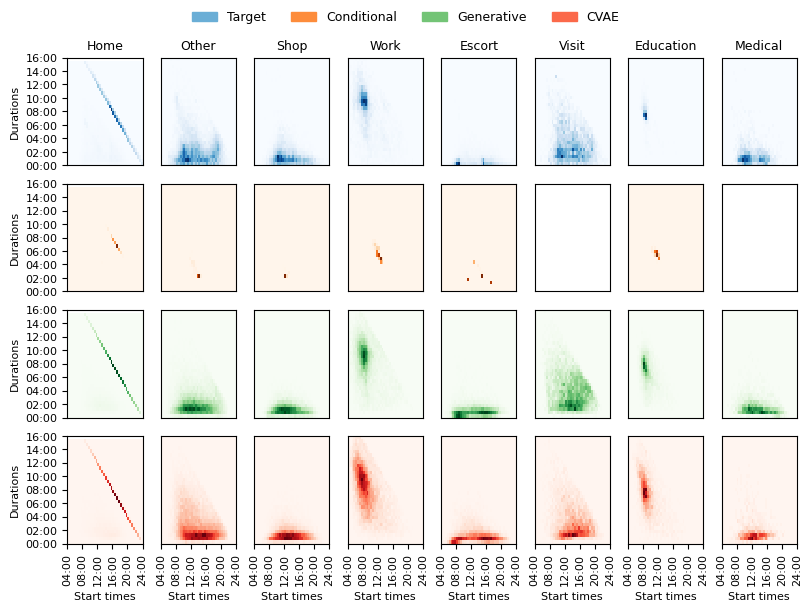

In [181]:
fig = joint_time_distributions_plot(
    target_schedules,
    schedules,
    figsize=(8, 6),
    observed_title="Target",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)

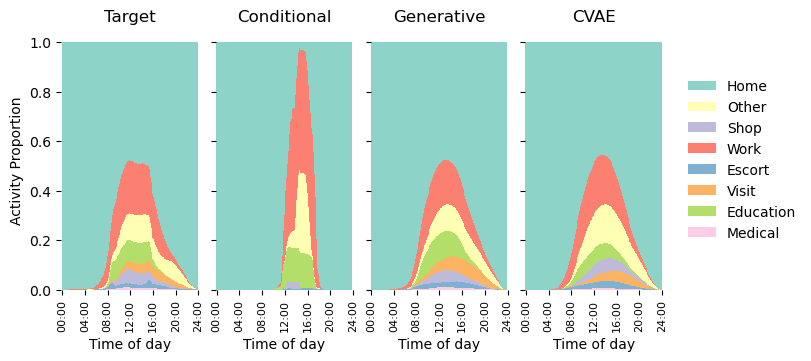

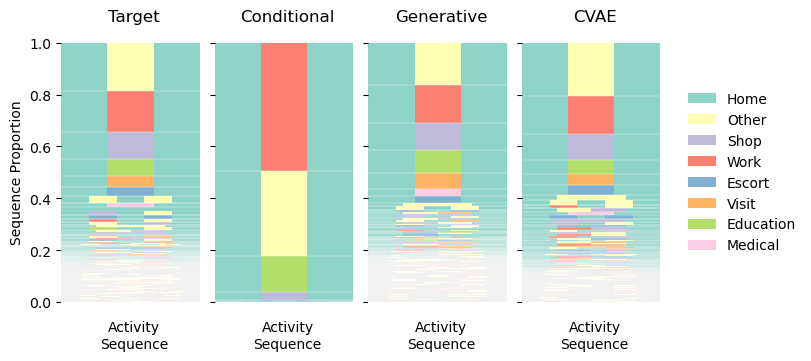

In [182]:
# fig = times_distributions_plot(
#     target_schedules, schedules, observed_title="Target", figsize=(9, 5)
# )
fig = frequency_plots(
    target_schedules,
    schedules,
    color=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)
fig = sequence_prob_plot(
    target_schedules,
    schedules,
    cmap=cmap,
    figsize=(8, 3.5),
    observed_title="Target",
)

In [230]:
import random

from pam.core import Household, Person
from pam.plot.plans import plot_household

from caveat.data.utils import trace_to_pam


def stretch(schedules):
    return schedules.groupby(schedules.pid).apply(stretcher)


def stretcher(schedule):
    duration = schedule.duration.sum()
    if duration != 1440:
        a = 1440 / duration
        schedule.duration = (schedule.duration * a).astype(int)
        accumulated = list(schedule.duration.cumsum())
        schedule.start = [0] + accumulated[:-1]
        schedule.end = accumulated
    return schedule


def trim(schedules):
    schedules[schedules.end > 1440] = 1440
    schedules[schedules.start > 1440] = 1440
    schedules.duration = schedules.end - schedules.start
    schedules = schedules[schedules.duration > 0]
    return schedules


def pad(schedules):
    return (
        schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
    )


def padder(schedule):
    if schedule.end.iloc[-1] < 1440 and schedule.act.iloc[-1] != "home":
        pid = schedule.pid.iloc[0]
        schedule = pd.concat(
            [
                schedule,
                DataFrame(
                    {
                        "pid": pid,
                        "start": schedule.end.iloc[-1],
                        "end": 1440,
                        "duration": 1440 - schedule.end.iloc[-1],
                        "act": "home",
                    },
                    index=[0],
                ),
            ]
        )
    elif schedule.end.iloc[-1] < 1440:
        schedule.end.iloc[-1] = 1440
        schedule.duration.iloc[-1] = 1440 - schedule.start.iloc[-1]
    return schedule


def plot_schedules(schedules, **kwargs):
    cmap = {
        "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
        "other": (1.0, 1.0, 0.7019607843137254),
        "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
        "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
        "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
        "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
        "education": (
            0.7019607843137254,
            0.8705882352941177,
            0.4117647058823529,
        ),
        "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
        "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
    }
    cmap = {n.title(): c for n, c in cmap.items()}

    hh = Household("")
    pids = schedules.pid
    selected = random.sample(list(pids), 5)
    for i, pid in enumerate(selected):
        person = Person(pid)
        plan = schedules[schedules.pid == pid]
        plan = trim(stretch(pad(plan)))[["act", "start", "end", "duration"]]
        mapping = {a: a for a in plan.act}

        trace = [
            (row.act, row.start, row.end, row.duration)
            for i, row in plan.iterrows()
        ]
        plan = trace_to_pam(trace, mapping)

        person = Person(i)
        person.plan = plan
        hh.add(person)

    plot_household(hh, cmap=cmap, width=25)

/tmp/ipykernel_1548992/280007802.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_1548992/280007802.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_1548992/280007802.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping 

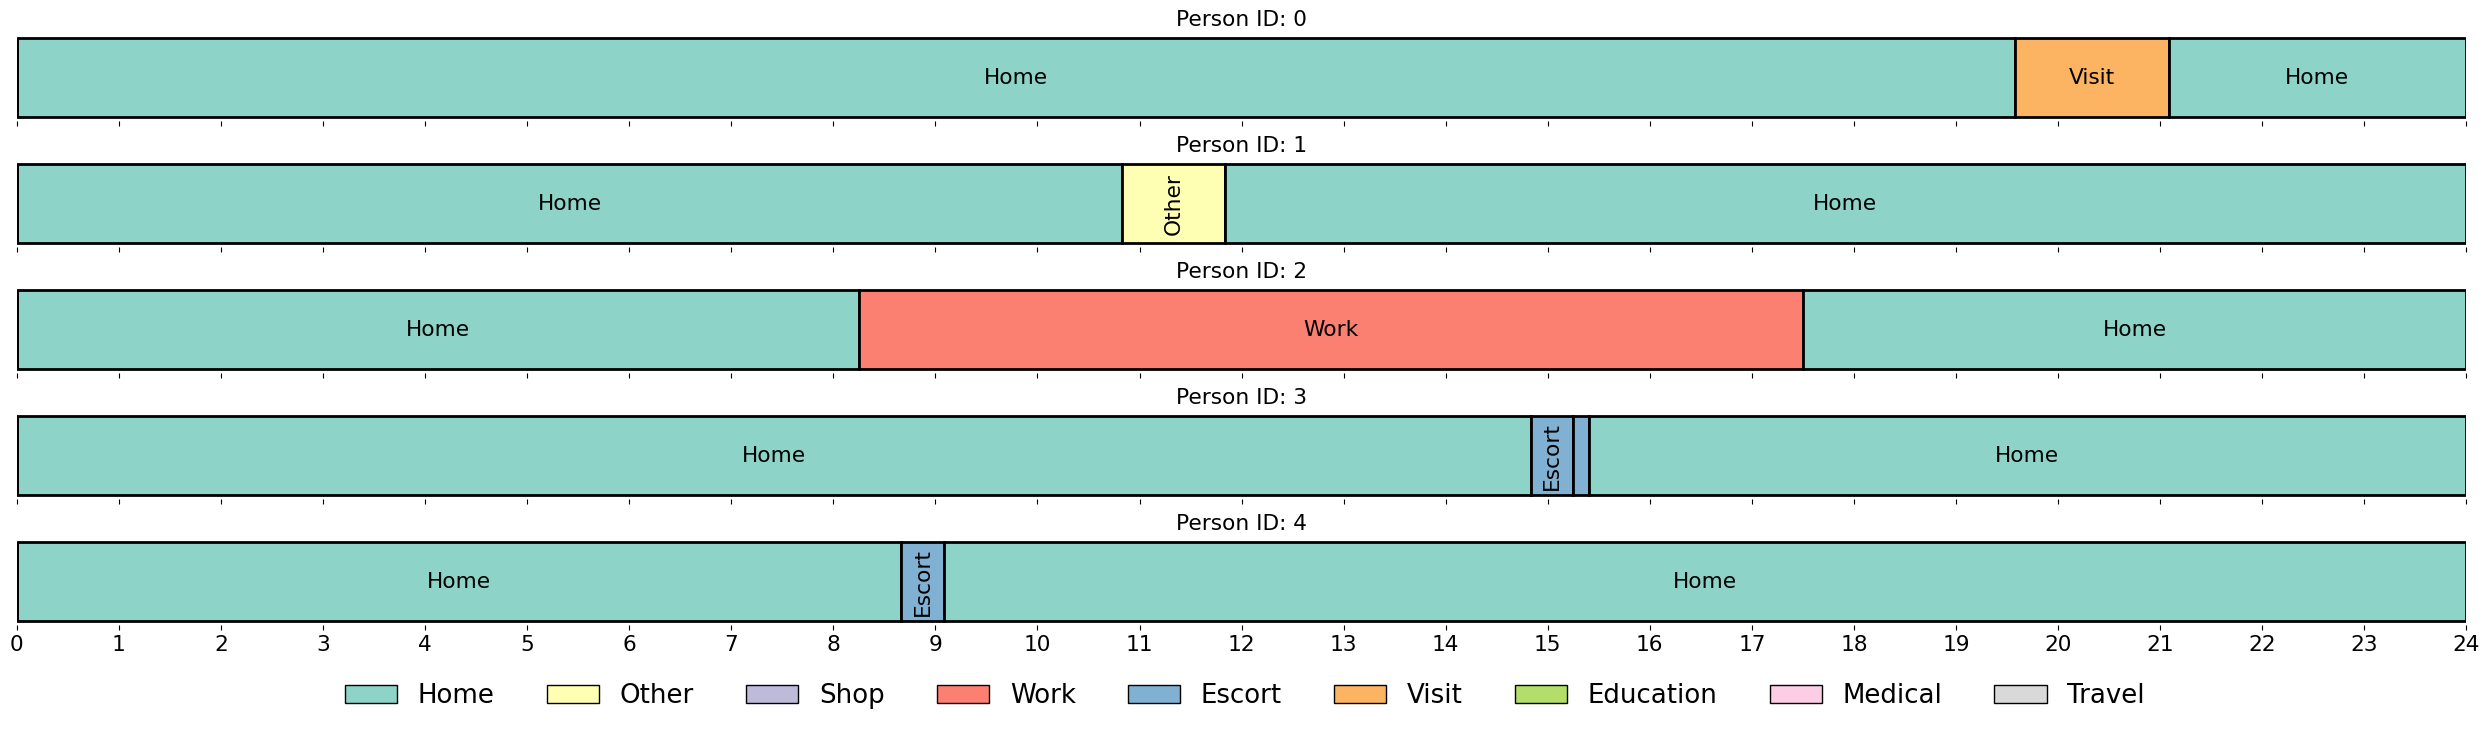

In [237]:
plot_schedules(target_schedules)

/tmp/ipykernel_1548992/280007802.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  schedules.groupby(schedules["pid"]).apply(padder).reset_index(drop=True)
/tmp/ipykernel_1548992/280007802.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return schedules.groupby(schedules.pid).apply(stretcher)
/tmp/ipykernel_1548992/280007802.py:34: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping 

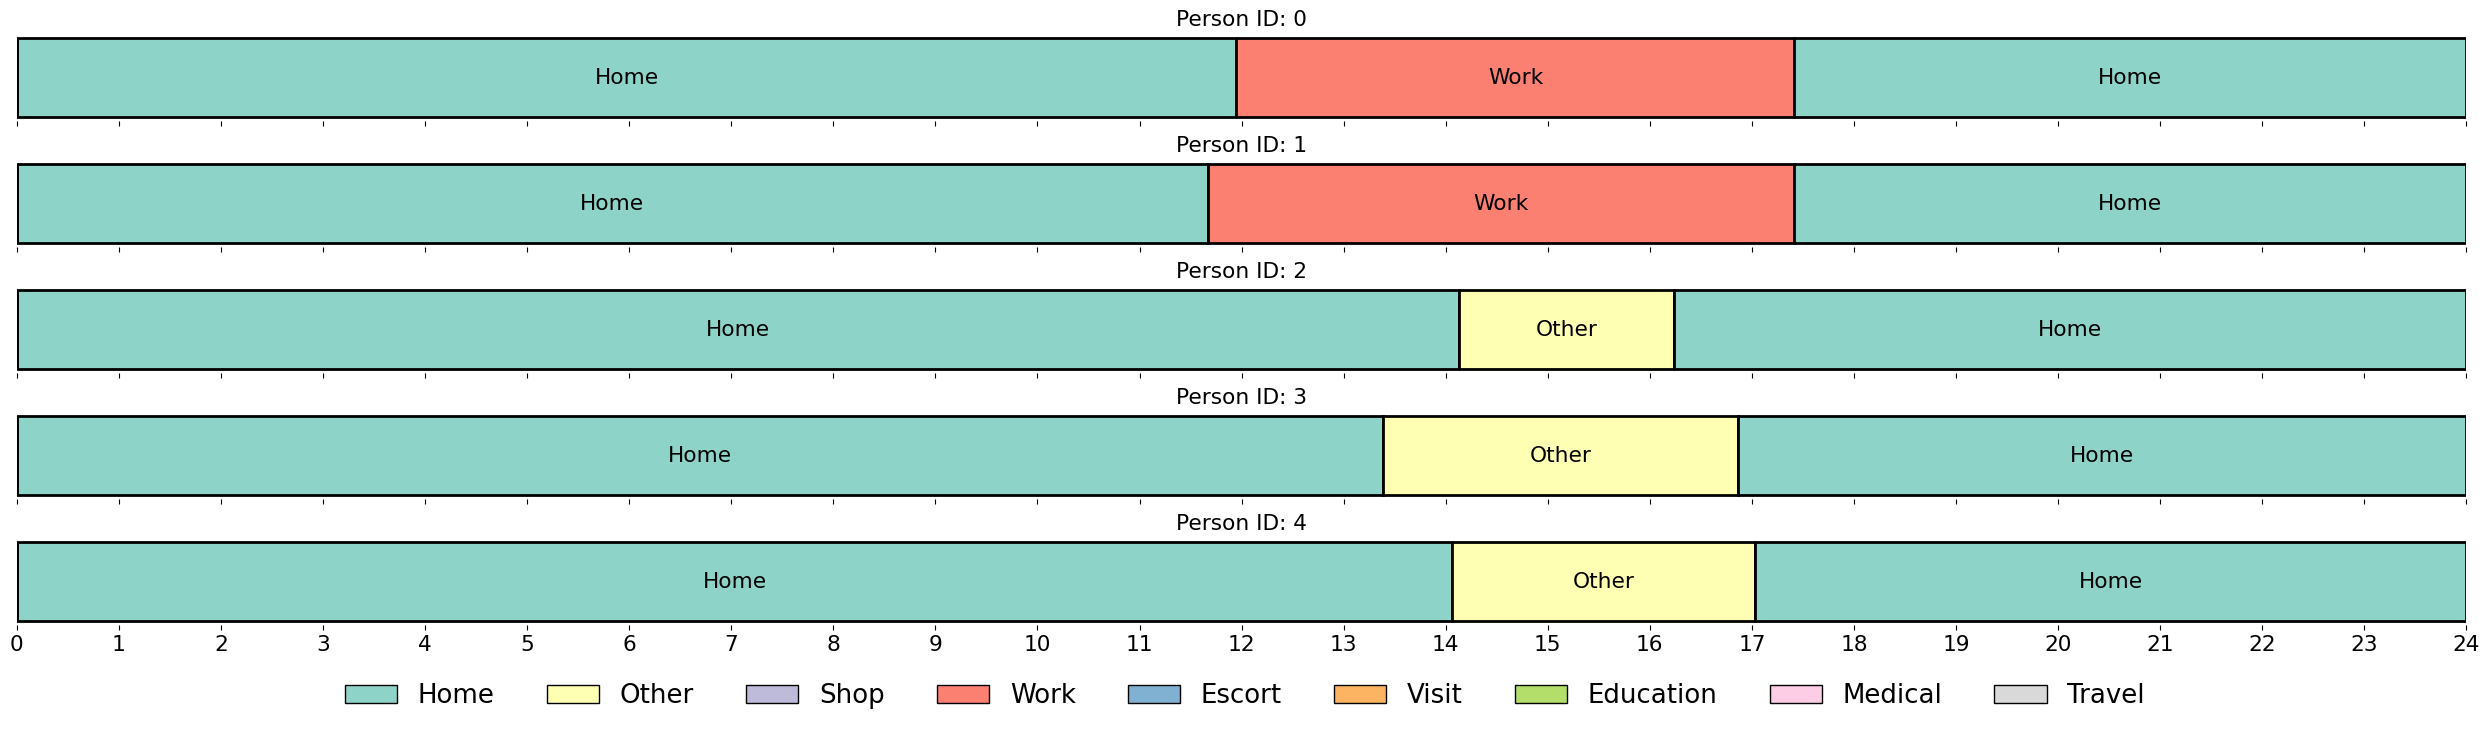

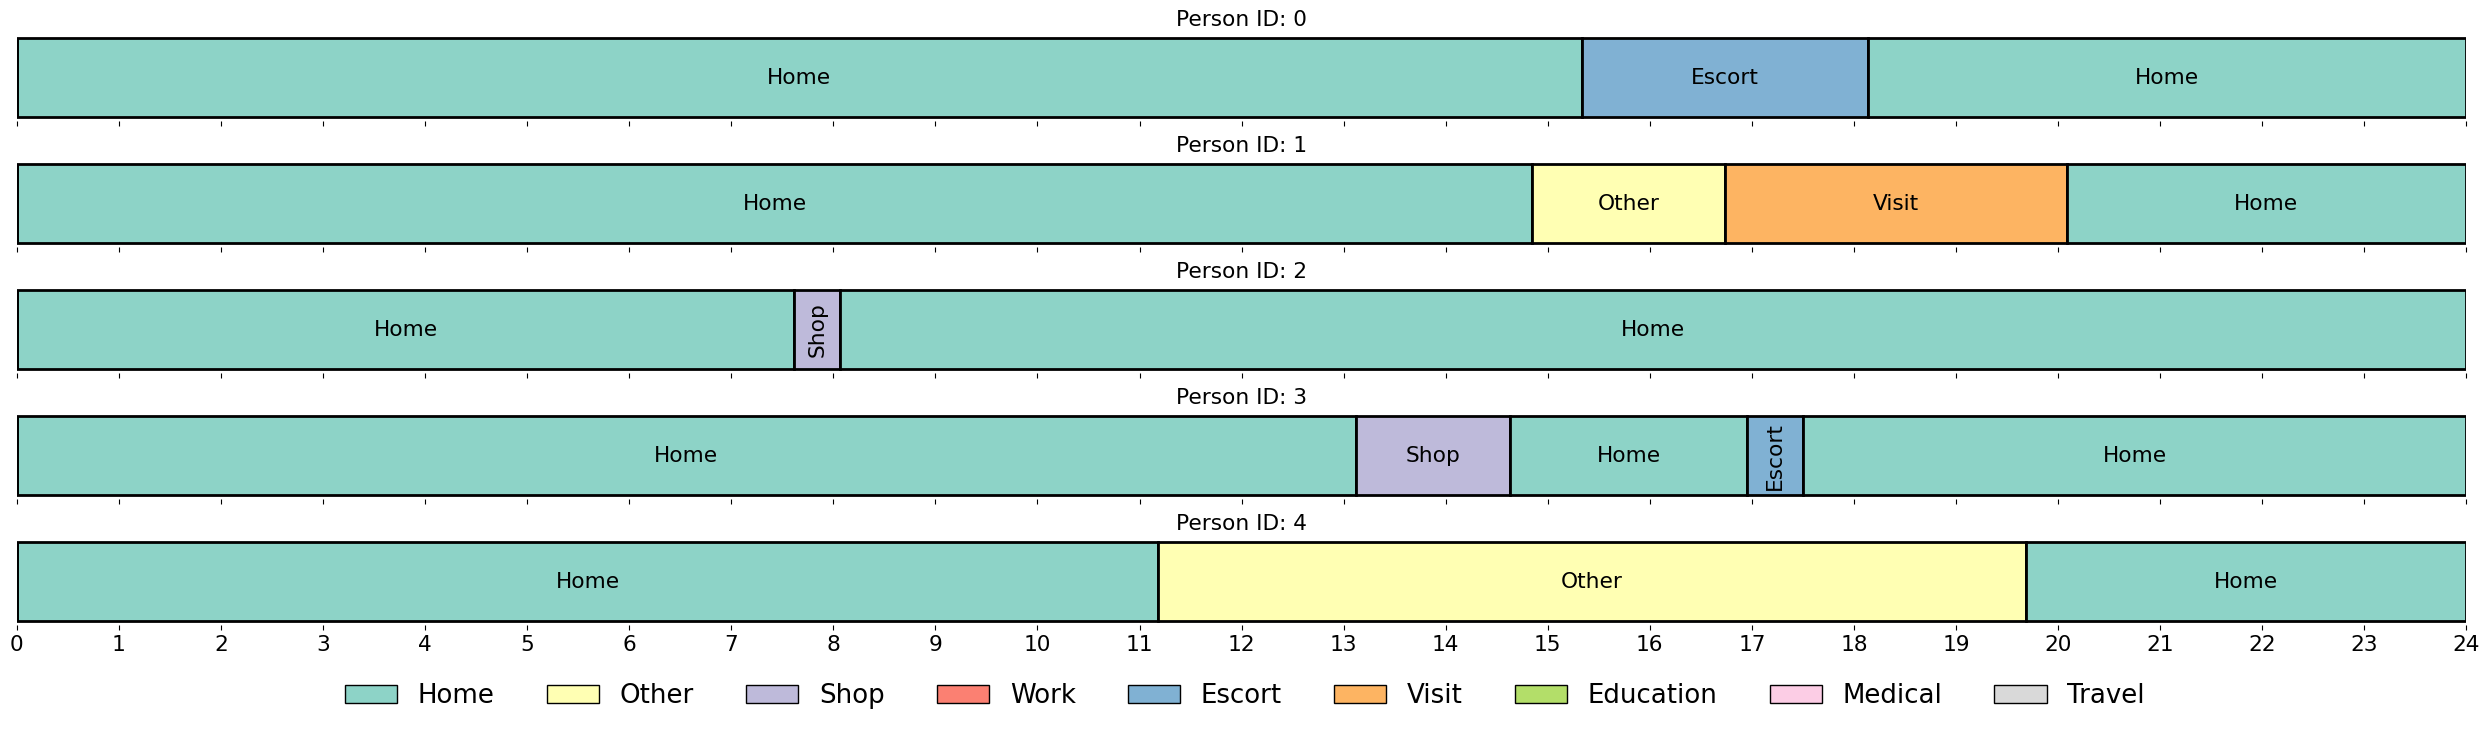

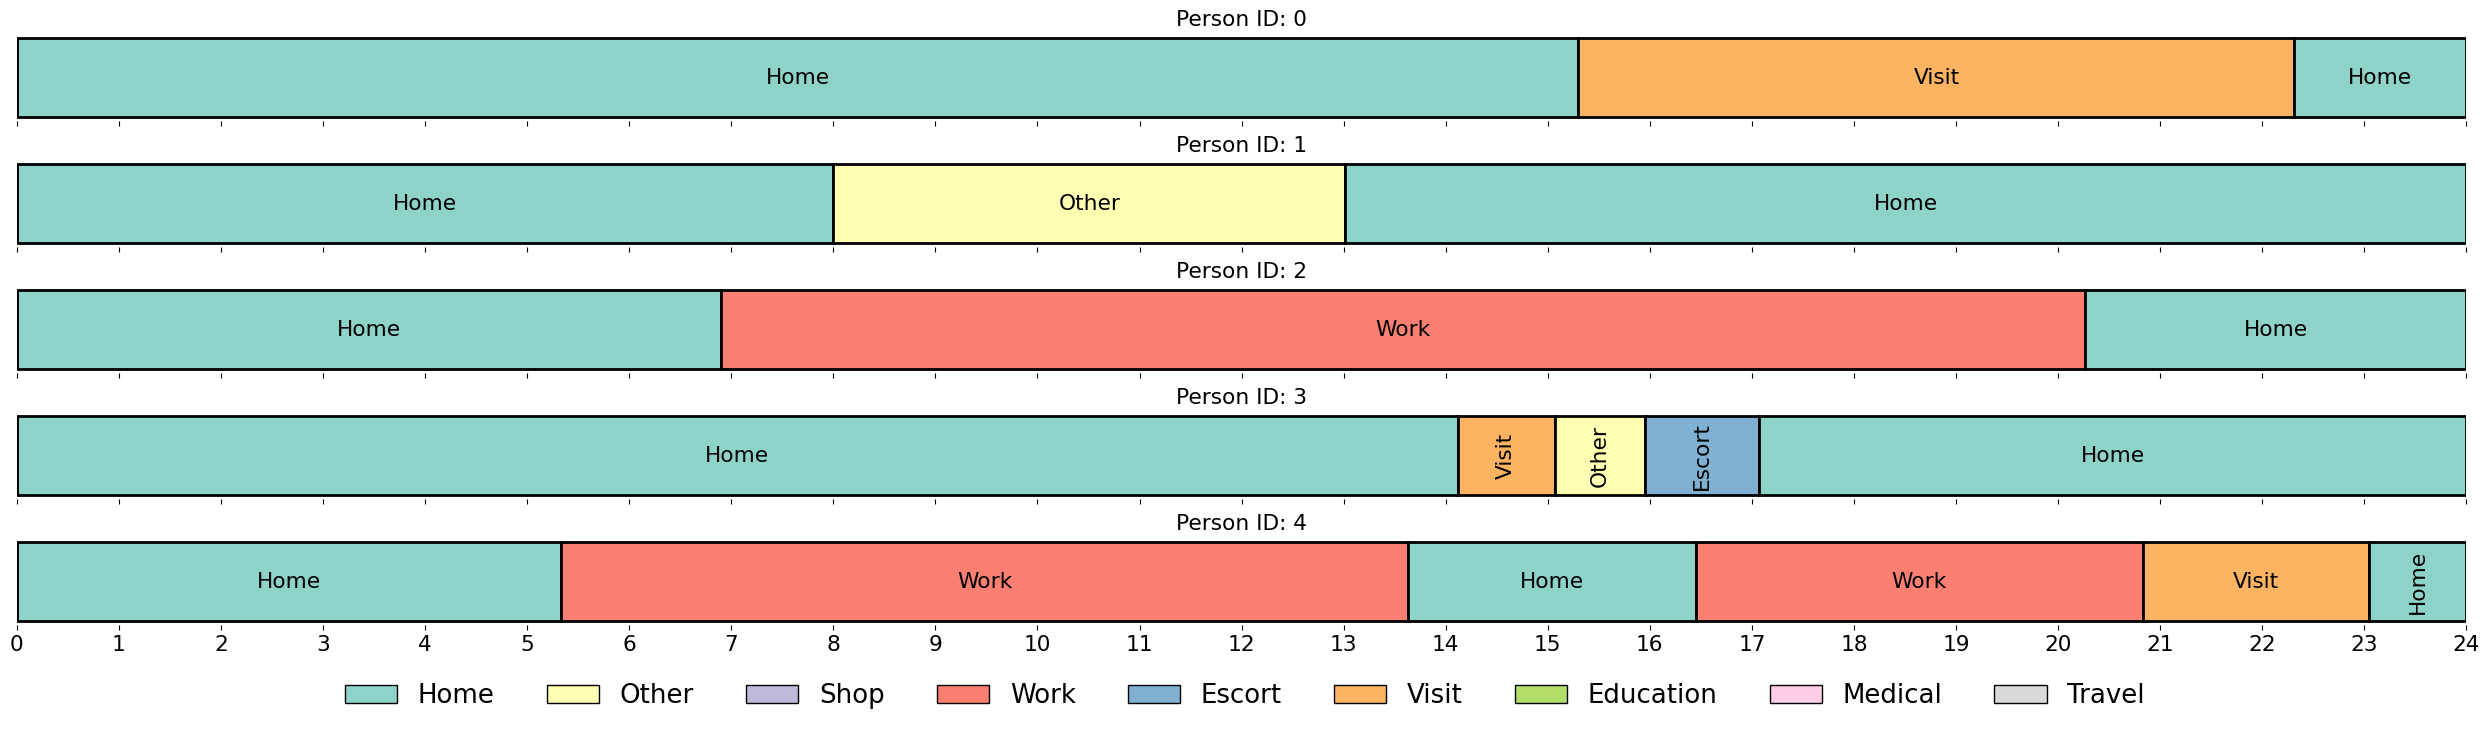

In [238]:
for n, p in batch_paths.items():
    examples = pd.read_csv(next(find_nth(p))[1] / "synthetic_schedules.csv")
    plot_schedules(examples)

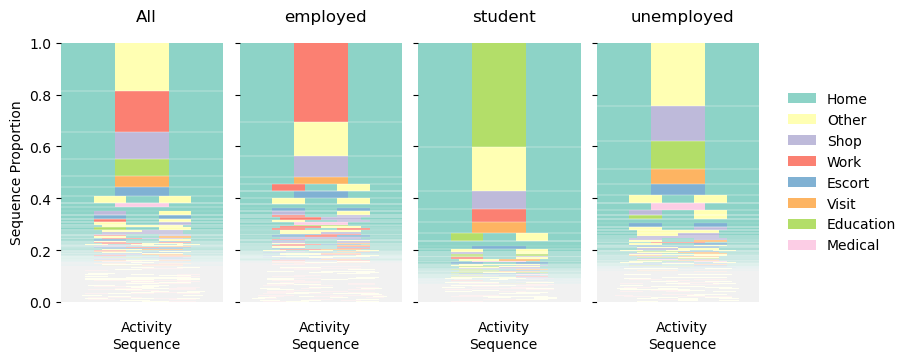

In [15]:
splits = split_on(target_schedules, target_attributes)
fig = describe_transitions.sequence_prob_plot(
    target_schedules, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
)

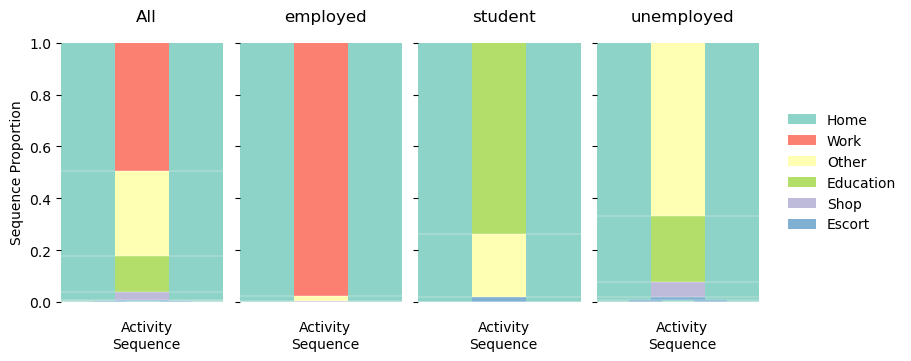

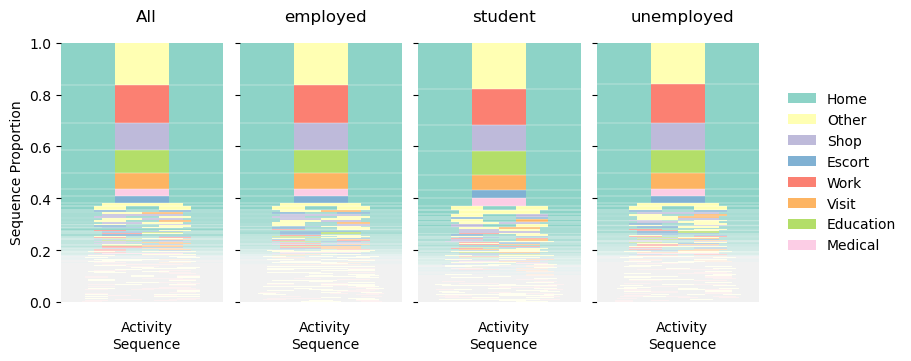

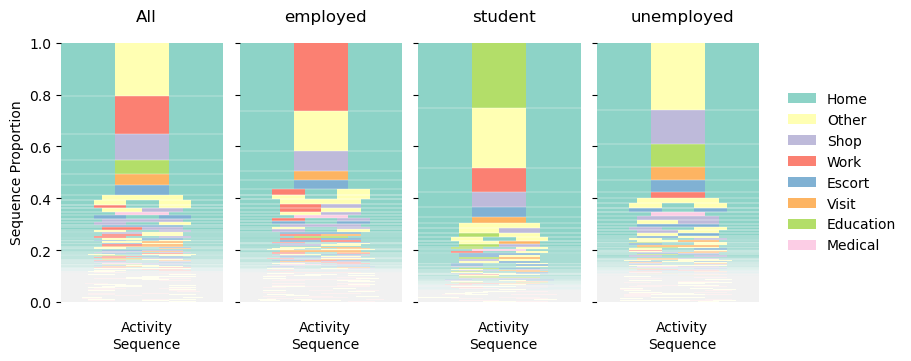

In [16]:
for k, scheds in schedules.items():
    splits = split_on(scheds, attributes[k])
    fig = describe_transitions.sequence_prob_plot(
        scheds, splits, observed_title="All", cmap=cmap, figsize=(9, 3.5)
    )

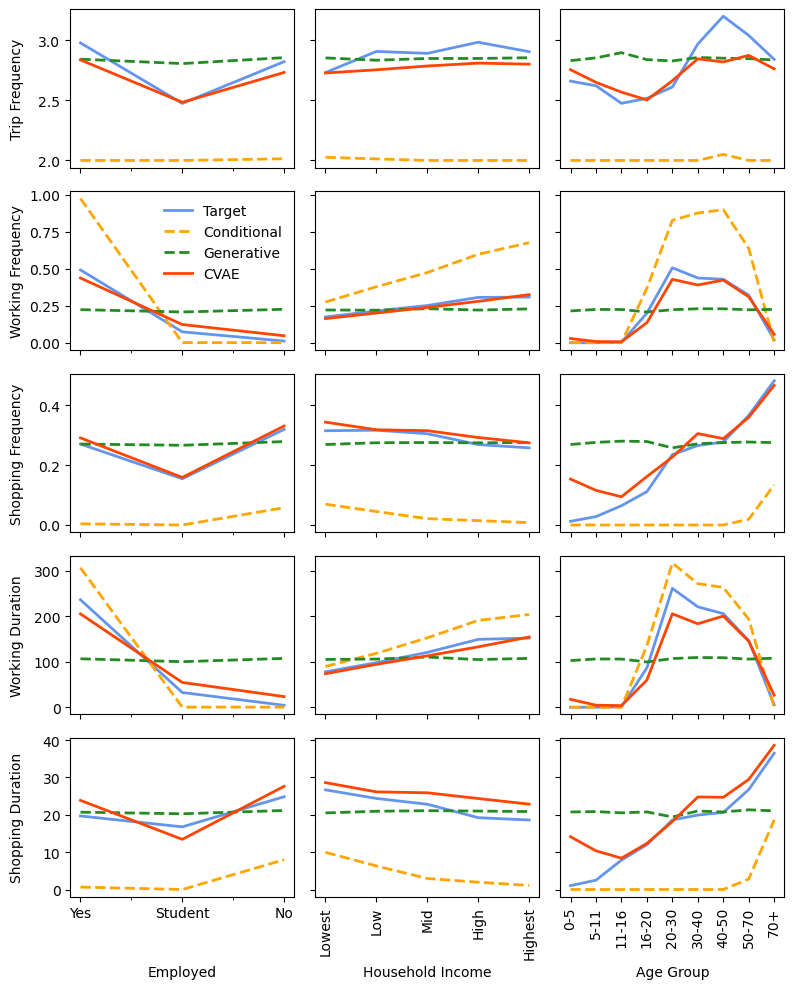

In [104]:
def duration(schedules, act="work"):
    n = schedules.pid.nunique()
    return schedules[schedules.act == act].duration.sum() / n


def count_trips(schedules):
    n = schedules.pid.nunique()
    return (len(schedules) - n) / n


def count_acts(schedules, act="work"):
    n = schedules.pid.nunique()
    return len(split.loc[split.act == act]) / n


age_order = [
    "<5",
    "5-11",
    "11-16",
    "16-20",
    "20-30",
    "30-40",
    "40-50",
    "50-70",
    "70+",
]
ages = [
    "0-5",
    "5-11",
    "11-16",
    "16-20",
    "20-30",
    "30-40",
    "40-50",
    "50-70",
    "70+",
]
colours = ["cornflowerblue", "orange", "forestgreen", "orangered"]
styles = ["-", "--", "--", "-"]

fig, axs = plt.subplots(5, 3, figsize=(8, 10), sharex="col", sharey="row")

# ==============================
# trips employment
splits = split_on(target_schedules, target_attributes, by="work_status")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_trips(split)

for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="work_status")
    for i, split in splits.items():
        data[n][i] = count_trips(split)

df = pd.DataFrame(data)
ax = axs[0][0]
df.plot(ax=ax, color=colours, style=styles, lw=2)
ax.set_ylabel("Trip Frequency")
ax.legend().remove()

# ==============================
# trips income
splits = split_on(target_schedules, target_attributes, by="income")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_trips(split)

for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="income")
    for i, split in splits.items():
        data[n][i] = count_trips(split)

df = pd.DataFrame(data)
ax = axs[0][1]
df.plot(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()

# ==================================
# trips age group
splits = split_on(target_schedules, target_attributes, by="age_group")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_trips(split)

for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="age_group")
    for i, split in splits.items():
        data[n][i] = count_trips(split)

df = pd.DataFrame(data)
ax = axs[0][2]
df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()

# =================================
# work employment

splits = split_on(target_schedules, target_attributes, by="work_status")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_acts(split)


for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="work_status")
    for i, split in splits.items():
        data[n][i] = count_acts(split)

df = pd.DataFrame(data)
ax = axs[1][0]
df.plot(ax=ax, color=colours, style=styles, lw=2)
ax.set_ylabel("Working Frequency")
ax.legend().remove()

# =================================
# work income

splits = split_on(target_schedules, target_attributes, by="income")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_acts(split)


for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="income")
    for i, split in splits.items():
        data[n][i] = count_acts(split)

df = pd.DataFrame(data)
ax = axs[1][1]
df.plot(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()

# ====================================
# work age group

splits = split_on(target_schedules, target_attributes, by="age_group")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_acts(split)


for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="age_group")
    for i, split in splits.items():
        data[n][i] = count_acts(split)

df = pd.DataFrame(data)
ax = axs[1][2]
df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()

# =================================
# shop employment

splits = split_on(target_schedules, target_attributes, by="work_status")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_acts(split, act="shop")


for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="work_status")
    for i, split in splits.items():
        data[n][i] = count_acts(split, act="shop")

df = pd.DataFrame(data)
ax = axs[2][0]
df.plot(ax=ax, color=colours, style=styles, lw=2)
ax.set_ylabel("Shopping Frequency")
ax.legend().remove()

# =================================
# shop income

splits = split_on(target_schedules, target_attributes, by="income")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_acts(split, act="shop")


for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="income")
    for i, split in splits.items():
        data[n][i] = count_acts(split, act="shop")

df = pd.DataFrame(data)
ax = axs[2][1]
df.plot(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()

# ====================================
# shop age group

splits = split_on(target_schedules, target_attributes, by="age_group")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = count_acts(split, act="shop")


for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="age_group")
    for i, split in splits.items():
        data[n][i] = count_acts(split, act="shop")

df = pd.DataFrame(data)
ax = axs[2][2]
df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()

# ====================================
# work employment

splits = split_on(target_schedules, target_attributes, by="work_status")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = duration(split)

for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="work_status")
    for i, split in splits.items():
        data[n][i] = duration(split)

df = pd.DataFrame(data)
ax = axs[3][0]
df.plot(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()
ax.set_ylabel("Working Duration")

# ====================================
# work income

splits = split_on(target_schedules, target_attributes, by="income")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = duration(split)

for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="income")
    for i, split in splits.items():
        data[n][i] = duration(split)

df = pd.DataFrame(data)
ax = axs[3][1]
df.plot(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()

# ====================================
# work age group

splits = split_on(target_schedules, target_attributes, by="age_group")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = duration(split)

for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="age_group")
    for i, split in splits.items():
        data[n][i] = duration(split)

df = pd.DataFrame(data)
ax = axs[3][2]
df.loc[age_order].plot(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()

# ====================================
# shop employment

splits = split_on(target_schedules, target_attributes, by="work_status")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = duration(split, act="shop")

for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="work_status")
    for i, split in splits.items():
        data[n][i] = duration(split, act="shop")

df = pd.DataFrame(data)
ax = axs[4][0]
df.plot(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()
ax.set_ylabel("Shopping Duration")
ax.set_xlabel("Employed")
ax.set_xticks([0, 1, 2], ["Yes", "Student", "No"], rotation=0)

# ====================================
# shop income

splits = split_on(target_schedules, target_attributes, by="income")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = duration(split, act="shop")

for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="income")
    for i, split in splits.items():
        data[n][i] = duration(split, act="shop")

df = pd.DataFrame(data)
ax = axs[4][1]
df.plot(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()
ax.set_xlabel("Household Income")
ax.set_xticks(
    [1, 2, 3, 4, 5], ["Lowest", "Low", "Mid", "High", "Highest"], rotation=90
)

# ====================================
# shop age group

splits = split_on(target_schedules, target_attributes, by="age_group")
data = {"Target": {}}
for i, split in splits.items():
    data["Target"][i] = duration(split, act="shop")

for n, scheds in schedules.items():
    data[n] = {}
    atts = attributes[n]
    splits = split_on(scheds, atts, by="age_group")
    for i, split in splits.items():
        data[n][i] = duration(split, act="shop")

df = pd.DataFrame(data)
ax = axs[4][2]
df.loc[age_order].plot.line(ax=ax, color=colours, style=styles, lw=2)
ax.legend().remove()
ax.set_xlabel("Age Group")
ax.set_xticks(range(len(ages)), ages, rotation=90)

# for ax in axs.flat:
#     ax.grid(visible=True, which="major", axis="x", color="grey", linestyle="-")

axs[1][0].legend(loc="upper right", frameon=False, fontsize=10)

fig.align_ylabels(axs[:, 0])
fig.align_xlabels(axs[-1, :])


fig.tight_layout()

In [239]:
# Ageing Scenario
attributes = {
    2023: pd.read_csv(Path("../tmp/nts_attributes_2023.csv")),
    2033: pd.read_csv(Path("../tmp/nts_attributes_2023_aged10.csv")),
    2043: pd.read_csv(Path("../tmp/nts_attributes_2023_aged20.csv")),
    2053: pd.read_csv(Path("../tmp/nts_attributes_2023_aged30.csv")),
}
demographics = (
    pd.DataFrame(
        {year: a.age_group.value_counts() for year, a in attributes.items()}
    )
    .loc[
        [
            "<5",
            "5-11",
            "11-16",
            "16-20",
            "20-30",
            "30-40",
            "40-50",
            "50-70",
            "70+",
        ]
    ]
    .fillna(0)
)
print(demographics.to_latex(float_format="{:.3f}".format, index=True))
demographics

\begin{tabular}{lrrrr}
\toprule
 & 2023 & 2033 & 2043 & 2053 \\
age_group &  &  &  &  \\
\midrule
<5 & 2454 & 0.000 & 0.000 & 0.000 \\
5-11 & 3563 & 352.000 & 0.000 & 0.000 \\
11-16 & 3489 & 5665.000 & 0.000 & 0.000 \\
16-20 & 1937 & 0.000 & 0.000 & 0.000 \\
20-30 & 4568 & 5761.000 & 6017.000 & 0.000 \\
30-40 & 7551 & 4233.000 & 5426.000 & 6017.000 \\
40-50 & 7681 & 7551.000 & 4568.000 & 5426.000 \\
50-70 & 17731 & 16322.000 & 15232.000 & 12119.000 \\
70+ & 10291 & 19381.000 & 28022.000 & 35703.000 \\
\bottomrule
\end{tabular}



,2023,2033,2043,2053
age_group,,,,
<5,2454,0.0,0.0,0.0
5-11,3563,352.0,0.0,0.0
11-16,3489,5665.0,0.0,0.0
16-20,1937,0.0,0.0,0.0
20-30,4568,5761.0,6017.0,0.0
30-40,7551,4233.0,5426.0,6017.0
40-50,7681,7551.0,4568.0,5426.0
50-70,17731,16322.0,15232.0,12119.0
70+,10291,19381.0,28022.0,35703.0


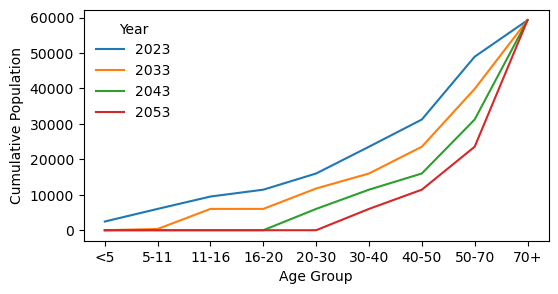

In [240]:
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(demographics.cumsum(axis=0))
ax.set_ylabel("Cumulative Population")
ax.set_xlabel("Age Group")
ax.legend(
    demographics.columns,
    loc="upper left",
    frameon=False,
    title="Year",
    title_fontsize=10,
)

In [241]:
aged_scenario = Path("../logs/TRB/cvae_ageing_scenario/descriptions.csv")
aged_scenario = pd.read_csv(aged_scenario)
aged_scenario.set_index(["domain", "feature", "segment"], inplace=True)
aged_scenario = aged_scenario.loc[
    ("participations"), ["a2023", "a2033", "a2043", "a2053"]
]
aged_scenario = aged_scenario.drop("pair participation rate", axis=0)
for c in ["a2033", "a2043", "a2053"]:
    aged_scenario[c] = aged_scenario[c].astype(float)
    aged_scenario[f"{c}"] = (
        100
        * (aged_scenario[c] - aged_scenario["a2023"])
        / aged_scenario["a2023"]
    )
print(
    aged_scenario.to_latex(
        float_format="{:.3f}".format, index=True, label="tab:aged_scenario"
    )
)

\begin{table}
\label{tab:aged_scenario}
\begin{tabular}{llrrrr}
\toprule
 &  & a2023 & a2033 & a2043 & a2053 \\
feature & segment &  &  &  &  \\
\midrule
lengths & sequence lengths & 3.833 & 0.151 & -2.239 & 0.698 \\
\cline{1-6}
\multirow[t]{8}{*}{participation rate} & education & 0.083 & -11.942 & -47.567 & -49.412 \\
 & escort & 0.224 & -12.532 & -13.088 & -18.764 \\
 & home & 2.267 & 0.956 & -1.102 & 1.622 \\
 & medical & 0.031 & -17.771 & 18.148 & 11.201 \\
 & other & 0.533 & 12.440 & 1.803 & 13.958 \\
 & shop & 0.295 & -7.383 & 8.309 & 11.609 \\
 & visit & 0.138 & -7.965 & 0.869 & 19.014 \\
 & work & 0.260 & -2.260 & -12.657 & -25.112 \\
\cline{1-6}
\bottomrule
\end{tabular}
\end{table}



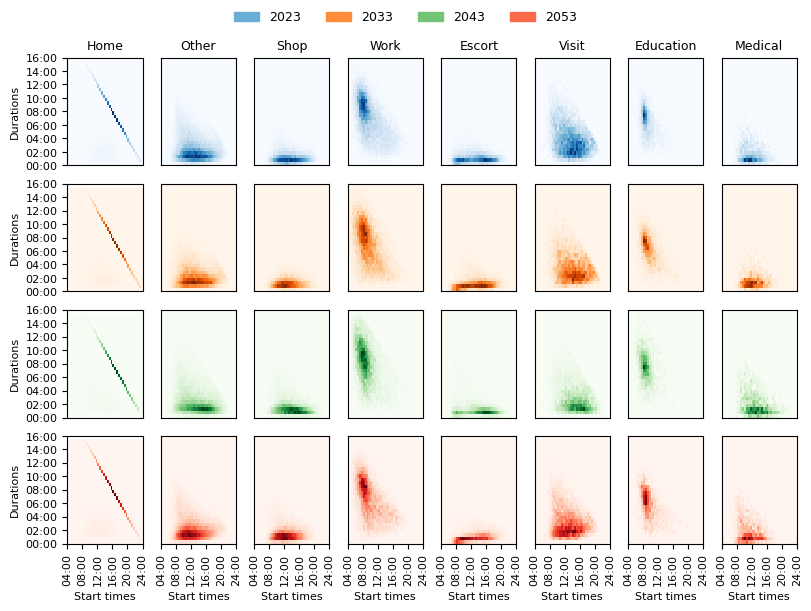

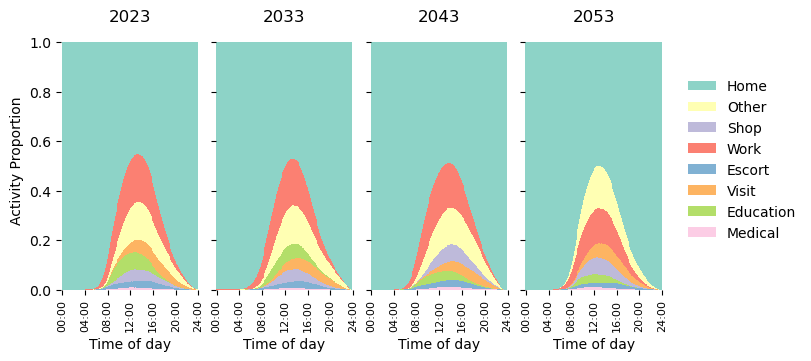

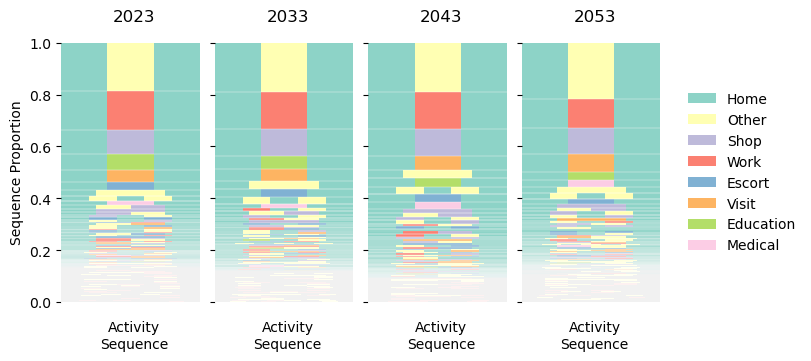

In [243]:
schedules = {
    year: pd.read_csv(
        latest(Path("../logs/TRB/cvae_ageing_scenario") / f"a{year}")[1]
        / "synthetic_schedules.csv"
    )
    for year in ["2023", "2033", "2043", "2053"]
}

base = schedules.pop("2023")

fig = joint_time_distributions_plot(
    base,
    schedules,
    figsize=(8, 6),
    observed_title="2023",
    cmaps={
        0: "Blues",
        1: "Oranges",
        2: "Greens",
        3: "Reds",
        4: "Purples",
        5: "Greys",
    },
)
fig = frequency_plots(
    base, schedules, color=cmap, figsize=(8, 3.5), observed_title="2023"
)
fig = describe_transitions.sequence_prob_plot(
    base, schedules, observed_title="2023", cmap=cmap, figsize=(8, 3.5)
)

In [27]:
# Sampling Scenario

sample_scenario = Path("../logs/TRB/cvae_sampled_scenario/domain_distances.csv")
sample_scenario = (
    pd.read_csv(sample_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    sample_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["s200", "s100", "s50", "s25", "s12"],
    ].to_latex(float_format="{:.3f}".format)
)

\begin{tabular}{lrrrrr}
\toprule
 & s200 & s100 & s50 & s25 & s12 \\
domain &  &  &  &  &  \\
\midrule
participations & 0.035 & 0.064 & 0.106 & 0.149 & 0.138 \\
transitions & 0.002 & 0.004 & 0.007 & 0.015 & 0.015 \\
timing & 0.017 & 0.024 & 0.032 & 0.048 & 0.062 \\
feasibility & 0.009 & 0.016 & 0.046 & 0.064 & 0.151 \\
creativity & 0.013 & 0.008 & 0.005 & 0.009 & 0.014 \\
\bottomrule
\end{tabular}



In [28]:
sample_scenario = Path(
    "../logs/TRB/cvae_sampled_scenario/domain_distances_subs.csv"
)
sample_scenario = (
    pd.read_csv(sample_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    sample_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["s200", "s100", "s50", "s25", "s12"],
    ].to_latex(float_format="{:.3f}".format)
)

\begin{tabular}{lrrrrr}
\toprule
 & s200 & s100 & s50 & s25 & s12 \\
domain &  &  &  &  &  \\
\midrule
participations & 0.050 & 0.072 & 0.108 & 0.154 & 0.148 \\
transitions & 0.003 & 0.005 & 0.009 & 0.019 & 0.020 \\
timing & 0.020 & 0.028 & 0.035 & 0.051 & 0.065 \\
feasibility & 0.009 & 0.016 & 0.046 & 0.064 & 0.151 \\
creativity & 0.010 & 0.005 & 0.003 & 0.004 & 0.007 \\
\bottomrule
\end{tabular}



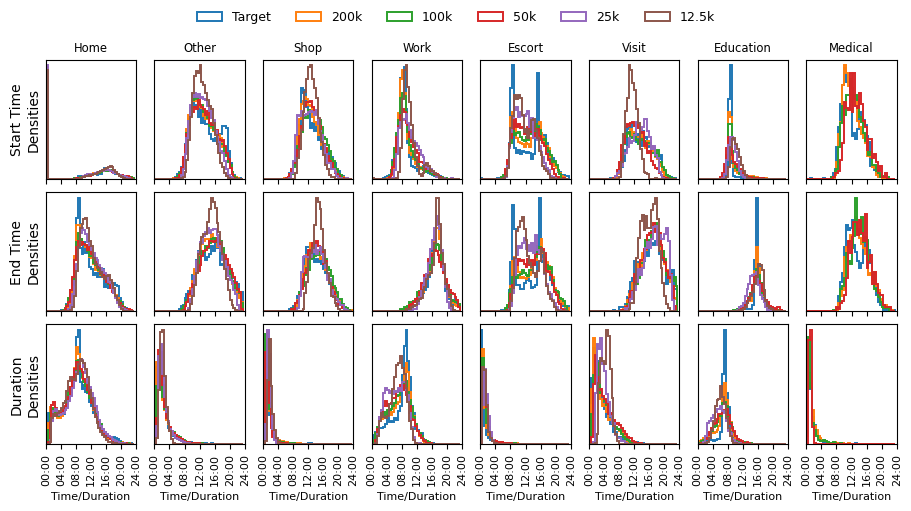

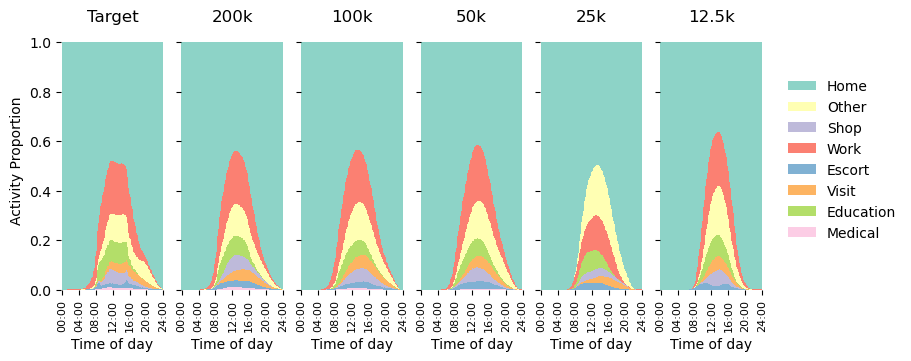

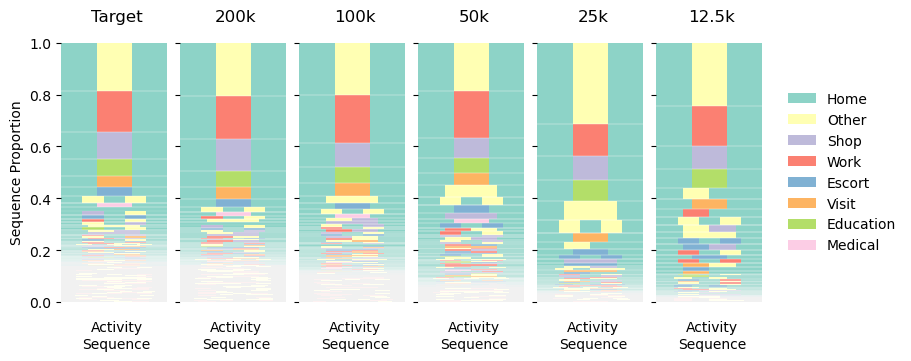

In [29]:
s200 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s200"))[1]
    / "synthetic_schedules.csv"
)
s100 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s100"))[1]
    / "synthetic_schedules.csv"
)

s50 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s50"))[1]
    / "synthetic_schedules.csv"
)
s25 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s25"))[1]
    / "synthetic_schedules.csv"
)
s12 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_sampled_scenario/s12"))[1]
    / "synthetic_schedules.csv"
)
# s6 = pd.read_csv(
#     latest(Path("../logs/TRB/cvae_sampled_scenario/s6"))[1]
#     / "synthetic_schedules.csv"
# )

sampled_schedules = {
    "200k": s200,
    "100k": s100,
    "50k": s50,
    "25k": s25,
    "12.5k": s12,
}

fig = times_distributions_plot(
    target_schedules, sampled_schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmap,
    figsize=(9, 3.5),
    observed_title="Target",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="Target",
    cmap=cmap,
    figsize=(9, 3.5),
)

In [30]:
# labels scenario
label_scenario = Path("../logs/TRB/cvae_labels_scenario/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8", "l16"]]

\begin{tabular}{lrrrrr}
\toprule
 & l1 & l2 & l4 & l8 & l16 \\
domain &  &  &  &  &  \\
\midrule
participations & 0.045 & 0.057 & 0.061 & 0.072 & 0.066 \\
transitions & 0.003 & 0.003 & 0.004 & 0.003 & 0.003 \\
timing & 0.019 & 0.022 & 0.032 & 0.026 & 0.023 \\
feasibility & 0.016 & 0.025 & 0.034 & 0.026 & 0.015 \\
creativity & 0.019 & 0.019 & 0.020 & 0.014 & 0.018 \\
\bottomrule
\end{tabular}



,l1,l2,l4,l8,l16
domain,,,,,
creativity,0.019292,0.019083,0.020058,0.013836,0.017586
feasibility,0.015651,0.024951,0.034090,0.026370,0.014569
participations,0.044673,0.057269,0.061144,0.072243,0.066395
timing,0.018651,0.021649,0.031574,0.026210,0.022591
transitions,0.002946,0.003325,0.003764,0.002773,0.002934


In [31]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/domain_distances_subs.csv"
)
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        ["participations", "transitions", "timing", "feasibility", "creativity"]
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario[["l1", "l2", "l4", "l8"]]

\begin{tabular}{lrrrrr}
\toprule
 & l1 & l2 & l4 & l8 & l16 \\
domain &  &  &  &  &  \\
\midrule
participations & 0.052 & 0.062 & 0.066 & 0.075 & 0.070 \\
transitions & 0.004 & 0.004 & 0.005 & 0.004 & 0.004 \\
timing & 0.021 & 0.024 & 0.033 & 0.028 & 0.027 \\
feasibility & 0.016 & 0.025 & 0.034 & 0.026 & 0.015 \\
creativity & 0.015 & 0.015 & 0.016 & 0.010 & 0.014 \\
\bottomrule
\end{tabular}



,l1,l2,l4,l8
domain,,,,
creativity,0.015474,0.015261,0.015994,0.010183
feasibility,0.015598,0.024871,0.033983,0.026284
participations,0.051976,0.061778,0.065847,0.074622
timing,0.021425,0.024486,0.033052,0.028314
transitions,0.003963,0.004189,0.004542,0.003746


In [32]:
label_scenario = Path(
    "../logs/TRB/cvae_labels_scenario/label_descriptions_subs.csv"
)
label_scenario = pd.read_csv(label_scenario)
label_scenario = label_scenario.loc[
    label_scenario.cat.isin(["employed", "unemployed"])
]
label_scenario = label_scenario.set_index(
    ["domain", "feature", "segment", "label", "cat"]
).drop("unit", axis=1)


def aggregate_label_scenario(label_scenario):
    agg = {}
    for c in ["observed", "l1", "l2", "l4", "l8"]:
        agg[c] = (
            label_scenario[c] * label_scenario[f"{c}__weight"]
        ).sum() / label_scenario[f"{c}__weight"].sum()
    return pd.Series(agg)


label_scenario.groupby(["domain", "cat"]).apply(aggregate_label_scenario)

observed        l1        l2        l4        l8
domain         cat                                                         
creativity     employed    0.856972  0.983961  0.986623  0.982862  0.989651
               unemployed  0.828239  0.984860  0.982292  0.984996  0.989609
feasibility    employed    0.000000  0.006386  0.010277  0.013853  0.011462
               unemployed  0.000000  0.005441  0.008407  0.011088  0.008149
participations employed    0.210674  0.204022  0.205696  0.202315  0.204494
               unemployed  0.202714  0.203793  0.206730  0.198519  0.196744
timing         employed    0.453887  0.460936  0.457452  0.462670  0.459659
               unemployed  0.447872  0.449410  0.447794  0.451739  0.458147
transitions    employed    0.007494  0.009721  0.010408  0.013428  0.008272
               unemployed  0.008813  0.009448  0.008470  0.011737  0.008905

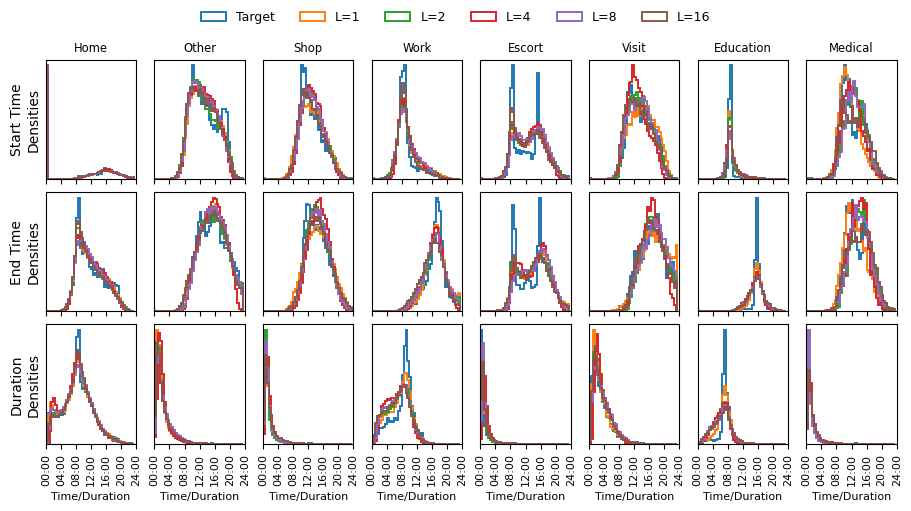

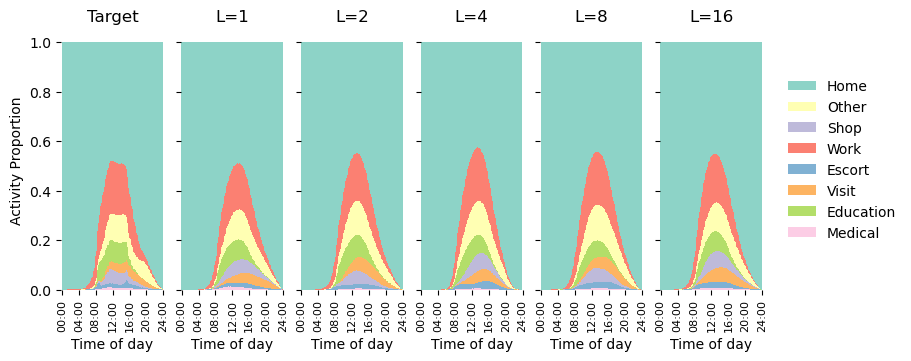

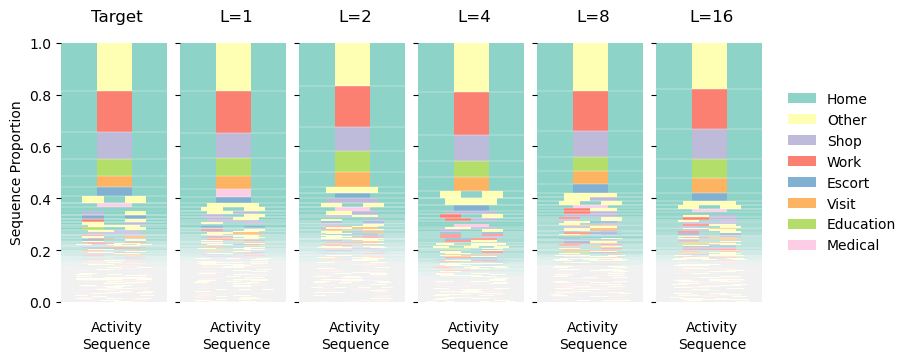

In [33]:
l1 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l1"))[1]
    / "synthetic_schedules.csv"
)

l2 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l2"))[1]
    / "synthetic_schedules.csv"
)
l4 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l4"))[1]
    / "synthetic_schedules.csv"
)
l8 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l8"))[1]
    / "synthetic_schedules.csv"
)
l16 = pd.read_csv(
    latest(Path("../logs/TRB/cvae_labels_scenario/l16"))[1]
    / "synthetic_schedules.csv"
)

sampled_schedules = {"L=1": l1, "L=2": l2, "L=4": l4, "L=8": l8, "L=16": l16}

fig = times_distributions_plot(
    target_schedules, sampled_schedules, observed_title="Target", figsize=(9, 5)
)
fig = frequency_plots(
    target_schedules,
    sampled_schedules,
    color=cmap,
    figsize=(9, 3.5),
    observed_title="Target",
)
fig = describe_transitions.sequence_prob_plot(
    target_schedules,
    sampled_schedules,
    observed_title="Target",
    cmap=cmap,
    figsize=(9, 3.5),
)

In [ ]:
# transfer scenario
label_scenario = Path("../logs/TRB/cvae_transfer_scenario/domain_distances.csv")
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["1yr_base", "transfer"],
    ].to_latex(float_format="{:.3f}".format)
)

label_scenario = Path(
    "../logs/TRB/cvae_transfer_scenario/domain_distances_subs.csv"
)
label_scenario = (
    pd.read_csv(label_scenario).set_index("domain").drop("observed", axis=1)
)
print(
    label_scenario.loc[
        [
            "participations",
            "transitions",
            "timing",
            "feasibility",
            "creativity",
        ],
        ["1yr_base", "transfer"],
    ].to_latex(float_format="{:.3f}".format)
)
label_scenario

\begin{tabular}{lrr}
\toprule
 & 1yr_base & transfer \\
domain &  &  \\
\midrule
participations & 0.070 & 0.048 \\
transitions & 0.003 & 0.002 \\
timing & 0.027 & 0.014 \\
feasibility & 0.026 & 0.006 \\
creativity & 0.013 & 0.027 \\
\bottomrule
\end{tabular}

\begin{tabular}{lrr}
\toprule
 & 1yr_base & transfer \\
domain &  &  \\
\midrule
participations & 0.080 & 0.061 \\
transitions & 0.004 & 0.003 \\
timing & 0.030 & 0.016 \\
feasibility & 0.026 & 0.006 \\
creativity & 0.008 & 0.018 \\
\bottomrule
\end{tabular}



,transfer,1yr_base
domain,,
creativity,0.017831,0.007827
feasibility,0.006104,0.025972
participations,0.061428,0.079677
timing,0.016328,0.030082
transitions,0.002599,0.004105


In [34]:
for n in ["aggregate", "participations", "transitions", "timing"]:
    print(n)
    print(table.loc[n].to_latex(float_format="{:.3f}".format))
    print()

aggregate


NameError: name 'table' is not defined

In [ ]:
def build_creativity_table(batch_paths):
    descriptions_combined = pd.DataFrame()
    distances_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = (
            pd.read_csv(path / "descriptions.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )
        distances = (
            pd.read_csv(path / "distances.csv")
            .set_index(["domain", "feature", "segment"])
            .loc["creativity"]
        )

        columns = set(descriptions.columns)
        weights = set([c for c in columns if "weight" in c])
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
            - weights
        )

        descriptions_combined[name, "desc."] = descriptions[columns].mean(
            axis=1
        )

        distances_combined[name, "dist."] = distances[columns].mean(axis=1)

    descriptions_combined["Observed", ""] = descriptions["observed"]
    descriptions_combined["Description", ""] = descriptions["description"]

    print(descriptions_combined.columns)

    descriptions_combined.columns = pd.MultiIndex.from_tuples(
        descriptions_combined.columns
    )

    distances_combined["Observed", ""] = distances["observed"]
    distances_combined["Description", ""] = distances["distance"]

    distances_combined.columns = pd.MultiIndex.from_tuples(
        distances_combined.columns
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    descriptions_combined = descriptions_combined.loc[:, order]

    order = list(distances_combined.columns)
    order.pop(order.index(("Observed", "")))
    order.pop(order.index(("Description", "")))
    order = [("Observed", "")] + order + [("Description", "")]
    distances_combined = distances_combined.loc[:, order]

    return pd.concat((descriptions_combined, distances_combined), axis=0)


table = build_creativity_table(batch_paths)
table

In [ ]:
print(table.loc["sample quality"].to_latex(float_format="{:.3f}".format))
table.loc["sample quality"]

In [ ]:
table.loc["creativity"]

In [ ]:
print(table.to_latex(float_format="{:.3f}".format))

In [ ]:
for domain in [
    "creativity",
    "sample quality",
    "aggregate",
    "participations",
    "transitions",
    "timing",
]:
    print()
    print(domain)
    print()
    ss = table.loc[domain]
    for feature in set(ss.reset_index()["feature"]):
        print(feature)
        print()
        print(ss.loc[feature].to_latex(float_format="{:.3f}".format))

In [ ]:
def build_subs_description_tables(batch_paths):
    descriptions_combined = pd.DataFrame()

    for name, path in batch_paths.items():

        descriptions = pd.read_csv(path / "descriptions_subs.csv").set_index(
            ["domain", "feature", "segment", "sub_pop"]
        )
        columns = set(descriptions.columns)
        columns = list(
            columns
            - set(["observed", "description", "mean", "std", "feature count"])
        )

        descriptions_combined[name] = descriptions[columns].mean(axis=1)

    descriptions_combined["Observed"] = descriptions["observed"]
    descriptions_combined["Description"] = descriptions["description"]

    descriptions_combined = (
        descriptions_combined.sort_values("Observed", ascending=False)
        .groupby(["domain", "feature", "sub_pop"])
        .head(100)
    )

    order = list(descriptions_combined.columns)
    order.pop(order.index("Observed"))
    order = ["Observed"] + order

    index = [
        "creativity",
        "sample quality",
        "aggregate",
        "participations",
        "transitions",
        "timing",
    ]

    return descriptions_combined.loc[index, order]


table = build_subs_description_tables(batch_paths)
table

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "work0",
    ["work_status=student", "work_status=employed"],
]

In [ ]:
table.loc[
    "participations",
    "participation rate",
    "education0",
    ["work_status=student", "work_status=employed"],
]